# Stellar Spectrum Analysis
**Instrument:** Celestron C8 + 0.66× focal reducer · Alpy 600 · ZWO ASI 533MM Pro  
**Resolution:** R ≈ 850 · SNR > 300 · Flux-normalised continuum  
**Scope:** Load the FITS file, plot the raw spectrum, and prepare for line identification.

*(The star name is read automatically from the FITS header `OBJNAME` keyword in Section 1 below.)*

---

## 0 · Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from astropy.io import fits

plt.rcParams['figure.dpi']       = 130
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.4
plt.rcParams['grid.linestyle']    = '--'
plt.rcParams['grid.linewidth']    = 0.4
plt.rcParams['font.size']         = 13
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.labelsize']    = 13
plt.rcParams['xtick.labelsize']   = 11
plt.rcParams['ytick.labelsize']   = 11
plt.rcParams['legend.fontsize']   = 11
plt.rcParams['figure.titlesize']  = 14

# ── Input file ───────────────────────────────────────────────────────────────
# Combined spectrum + error-bar FITS file produced by spectral_noise.ipynb
# (a 2-HDU file: primary HDU = flux, 'ERR' extension = 1-sigma noise_spectrum).
# Run spectral_noise.ipynb first to (re)generate this file from the raw +
# rectified spectrum pair.
FITS_FILE = '_6lac_20251212_758-spectrum-with-errors.fit'

# ── Wavelength range ────────────────────────────────────────────────────────
# Set to None to use the full range stored in the FITS file.
# Units: Ångström
WL_MIN = 3700   # e.g. 3700  |  None → use file start
WL_MAX = 6800   # e.g. 6750  |  None → use file end

# ── Line detection ───────────────────────────────────────────────────────────
# DETECTION_NSIGMA : peak height must exceed N × noise_spectrum(λ)
# PROMINENCE_NSIGMA: peak must rise N × NOISE_LEVEL above its surroundings
# MIN_DISTANCE_PX  : minimum pixel separation between two peaks
# MIN_FWHM_A       : discard peaks narrower than this (sub-instrumental spikes)
#                    Instrumental FWHM at R=850 is ~5.9 Å; 2 Å catches obvious CCD artefacts
# noise_spectrum and NOISE_LEVEL are no longer computed in this notebook -- they
# are read directly from FITS_FILE (see Section 1), having been produced by
# spectral_noise.ipynb.
DETECTION_NSIGMA  = 3     # peak height threshold (per-pixel, uses noise_spectrum)
PROMINENCE_NSIGMA = 5     # scalar prominence floor — raised to 5 with the cleaner noise window
MIN_DISTANCE_PX   = 3     # ~1.4 Å at 0.47 Å/px
MIN_FWHM_A        = 2.0   # Å — discard sub-instrumental spikes

# ── Balmer classification ────────────────────────────────────────────────────
# Rest wavelengths (air, Å) for Hε through Hα.
# Any detected peak within BALMER_TOL_A of a rest wavelength is labelled Balmer.
BALMER_LINES = {
    'H-9': 3835.4,
    'H-8': 3889.0,
    'Heps': 3970.1,
    'Hδ': 4101.74,
    'Hγ': 4340.47,
    'Hβ': 4861.33,
    'Hα': 6562.80,
}
BALMER_TOL_A = 8.0   # Å matching tolerance (~1.5× instrumental FWHM)

# ── Plotting ─────────────────────────────────────────────────────────────────
PANEL_WIDTH_A = 500   # Å per sub-panel
C_BALMER      = '#c0392b'   # red  — Balmer lines
C_OTHER       = '#2471a3'   # blue — other absorption
C_SPEC        = '#2c3e50'   # dark grey — spectrum trace

# ── Profile fitting ──────────────────────────────────────────────────────────
# BALMER_PROFILE = 'gaussian'  : all lines, including Balmer, → plain Gaussian
# BALMER_PROFILE = 'voigt'     : Balmer lines → single Voigt, others → Gaussian
# BALMER_PROFILE = 'composite' : Balmer lines → narrow Voigt core + broad
#                                 Gaussian wing (shared center), reported as two
#                                 rows both tagged Balmer; others → Gaussian.
#                                 Recommended for A-type and cooler stars, where
#                                 real Stark-broadened Balmer wings are wide
#                                 enough that a single Voigt underfits them —
#                                 the leftover wing flux otherwise gets picked
#                                 up by the deblender as spurious extra lines,
#                                 which can also mask real nearby metal lines
#                                 (e.g. Si II 4128/4130, Sr II 4077) that sit in
#                                 the wing region.
BALMER_PROFILE        = 'voigt'   # 'gaussian' | 'voigt' | 'composite'
FIT_HALFWIDTH_FWHM    = 3.0   # fit window half-width expressed in units of measured FWHM

# ── Deblending region search ─────────────────────────────────────────────────
# Walk outward from each peak centroid until the absorption depth falls below
# CONTINUUM_TOL × noise_spectrum(λ).  Smaller → tighter regions; larger → wider.
CONTINUUM_TOL  = 3.0   # σ  — continuum-reaching threshold
CONTEXT_PAD_A  = 15.0  # Å  — extra spectrum shown outside each region in the plot
N_PER_PAGE     = 6     # panels per figure page

# ── Deblend flag threshold ───────────────────────────────────────────────────
# Regions with SSR_norm >= SSR_DEBLEND_THRESHOLD are marked for multi-component
# deblending.  SSR_norm ≈ 1 means the single-component fit is noise-limited;
# values >> 1 indicate significant unmodelled structure (blends).
SSR_DEBLEND_THRESHOLD = 20.0

# ── Iterative deblending ─────────────────────────────────────────────────────
# RESIDUAL_NSIGMA : detect residual peaks above this × noise_spectrum(λ)
#                   Lower → catch weaker blended components; raise to reduce false positives
# MAX_COMP_PER_A  : maximum components allowed per Angstrom of region width
#   cap = max(n_seed_peaks, floor(width_A * MAX_COMP_PER_A) + 1)
#   0.15 comp/A works well for B–A stars at R~850
#   raise for cooler stars (G/K) with dense metallic forests
#   lower for very low-resolution spectra
# SSR_IMPROVE_MIN : minimum SSR_norm improvement ratio to accept a new component
#                   1.2 = accept if new SSR < old SSR / 1.2 (~17% improvement required)
RESIDUAL_NSIGMA  = 2.5
MAX_COMP_PER_A   = 0.15
SSR_IMPROVE_MIN  = 1.2

# ── Component validity filter ────────────────────────────────────────────────
# Components whose fitted FWHM exceeds MAX_FWHM_A are discarded after fitting.
# Physical reasoning: at R=850 the instrumental FWHM ≈ 5.9 Å; the broadest
# real stellar lines (Balmer, He I pressure-broadened) reach ~20 Å.  Anything
# wider is a degenerate flat pseudo-component used by the fitter to model the
# continuum residuals, not a real absorption line.
# Set to np.inf to disable the filter entirely.
MAX_FWHM_A = 20.0   # Å — applied to non-Balmer components; Balmer exempt

# ── Ghost-component amplitude filter ─────────────────────────────────────────
# The iterative deblender occasionally introduces a near-zero-amplitude
# component to soak up small-scale residual continuum structure rather than
# fit a real absorption line (e.g. amp ≈ 0.000-0.004 with an unremarkable
# FWHM that the MAX_FWHM_A filter above does not catch). These "ghost"
# components are discarded after fitting if their amplitude falls below
# MIN_AMP_NSIGMA × the local noise level (noise_spectrum at that wavelength).
# Applied to non-Balmer components only, mirroring MAX_FWHM_A. Set to 0 to
# disable the filter entirely.
MIN_AMP_NSIGMA = 2.0   # σ — minimum amplitude / local-noise ratio to keep a component

# ── Residual-driven amplitude ceiling (non-Balmer Gaussians) ────────────────
# Every plain Gaussian used to be allowed to fit up to amplitude 1.5
# regardless of how small the bump that justified adding it actually was.
# In a crowded blend, that let a component seeded from a modest residual
# balloon during the joint refit and compete with (or substitute for) an
# under-fit Balmer wing for the same flux — producing broad, implausibly
# deep "metal lines" that are really unclaimed Balmer wing flux in disguise.
# Each Gaussian's amplitude is now capped at AMP_CAP_FACTOR × the amplitude
# actually observed when it was proposed (measured single-peak depth for a
# Section 5 seed, or the residual height for a Stage 2 residual-added seed),
# with a small noise-floor so genuinely underestimated seeds aren't pinned
# shut. Set to a large number (e.g. 100) to effectively disable.
AMP_CAP_FACTOR = 2.0   # × the seed's own observed amplitude
# ────────────────────────────────────────────────────────────────────────────

# ── Plotting flags ───────────────────────────────────────────────────────────
# Every figure-producing section below can be switched on/off independently.
# Turn a flag off to skip that section's plotting entirely (the underlying
# calculations that other sections depend on are never skipped, only the
# figure generation / plt.show() calls are). All flags default to True.
PLOT_RAW_SPECTRUM        = False   # Sec. 2  · overview plot of the raw spectrum
PLOT_CLASSIFIED_FEATURES = False   # Sec. 5  · multi-panel Balmer/other classification plot
PLOT_FIT_OVERLAYS        = False   # Sec. 6  · multi-panel plot with profile-fit overlays
PLOT_DEBLEND_REGIONS     = False   # Sec. 7  · multi-page deblending-region plots
PLOT_SSR_DIAGNOSTICS     = False   # Sec. 8  · multi-page SSR_norm goodness-of-fit plots
PLOT_FLAGGED_DEBLEND     = False   # Sec. 9  · multi-page flagged/clean deblend plots
PLOT_DEBLEND_RESULTS     = False   # Sec. 10 · multi-page iterative-deblend result plots
PLOT_FINAL_OVERVIEW      = True   # Sec. 11 · final composite overview plot


## 1 · Load the FITS file
Reads the combined spectrum + error-bar FITS file produced by `spectral_noise.ipynb`:
the **primary HDU** holds the continuum-normalised flux (with the standard WCS
keywords `CRVAL1`, `CDELT1`, `CRPIX1`), and the **`ERR` extension** holds the
matching 1σ `noise_spectrum` array. The scalar reference-window noise level
(`NOISE_LEVEL`) is read from the `NOISELVL` header keyword.

In [2]:
def load(file_name):
    """Load a 1-D spectrum + its error bars from the FITS file written by
    spectral_noise.ipynb.

    Returns
    -------
    wavelength     : ndarray  [Å]
    flux           : ndarray  [normalised]
    noise_spectrum : ndarray  [normalised flux units] -- 1-sigma error bar per pixel
    header         : fits.Header  (primary HDU header)
    """
    hdul   = fits.open(file_name)
    header = hdul[0].header
    flux   = hdul[0].data.astype(float)   # convert big-endian float32 → float64

    if 'ERR' not in hdul:
        raise ValueError(
            f"'{file_name}' has no 'ERR' extension. Run spectral_noise.ipynb first "
            f"to produce a combined spectrum + error-bar FITS file."
        )
    noise_spectrum = hdul['ERR'].data.astype(float)

    crval = header.get('CRVAL1')           # reference wavelength [Å]
    cdelt = header.get('CDELT1')           # Å per pixel
    crpix = header.get('CRPIX1', 1)        # reference pixel (1-based)
    npix  = flux.size
    pixel = np.arange(npix)               # 0-based pixel index
    wavelength = crval + (pixel + 1 - crpix) * cdelt

    return wavelength, flux, noise_spectrum, header


def get_object_name(header, default='Unknown target'):
    """Extract the star's name from a FITS header (OBJNAME, then OBJECT)."""
    for key in ('OBJNAME', 'OBJECT'):
        name = header.get(key)
        if name:
            return str(name).strip()
    return default


def get_obs_date(header, default=None):
    """Extract the observation date (DATE-OBS) from a FITS header."""
    date = header.get('DATE-OBS')
    if date:
        return str(date).split('T')[0]   # keep date only, drop time-of-day
    return default


wavelength, flux, noise_spectrum, header = load(FITS_FILE)

# Scalar reference-window noise level and the window bounds, written into the
# header by spectral_noise.ipynb. NOISE_WL_MIN/MAX are kept only so Section 2
# can shade the original reference window for context.
NOISE_LEVEL  = header.get('NOISELVL')
NOISE_WL_MIN = header.get('NSEWLMIN')
NOISE_WL_MAX = header.get('NSEWLMAX')
if NOISE_LEVEL is None:
    raise ValueError(
        f"'{FITS_FILE}' has no NOISELVL keyword. Was it produced by "
        f"spectral_noise.ipynb?"
    )

OBJECT_NAME = get_object_name(header)
OBS_DATE    = get_obs_date(header)

print(f"Object    : {OBJECT_NAME}")
print(f"Obs. date : {OBS_DATE if OBS_DATE else 'n/a'}")
print(f"Generator : {header.get('COMMENT', 'n/a')}")
print(f"Pixels    : {flux.size}")
print(f"Dispersion: {header['CDELT1']:.4f} Å / px")
print(f"Full range: {wavelength[0]:.2f} – {wavelength[-1]:.2f} Å")
print(f"NOISE_LEVEL (reference-window sigma): {NOISE_LEVEL:.5f}")

# ── Apply wavelength limits ──────────────────────────────────────────────────
lo = WL_MIN if WL_MIN is not None else wavelength[0]
hi = WL_MAX if WL_MAX is not None else wavelength[-1]
mask = (wavelength >= lo) & (wavelength <= hi)
wavelength, flux, noise_spectrum = wavelength[mask], flux[mask], noise_spectrum[mask]

print(f"Working range: {wavelength[0]:.2f} – {wavelength[-1]:.2f} Å  ({wavelength.size} px)")
print(f"Flux      : min={flux.min():.4f}  max={flux.max():.4f}  mean={flux.mean():.4f}")


Object    : 6 Lac
Obs. date : 2025-12-12
Generator :    Generated by Visual Spec 4.6.8
Pixels    : 6389
Dispersion: 0.4852 Å / px
Full range: 3700.10 – 6799.81 Å
NOISE_LEVEL (reference-window sigma): 0.00364
Working range: 3700.10 – 6799.81 Å  (6389 px)
Flux      : min=0.6154  max=1.0119  mean=0.9816


## 2 · Plot the spectrum
Plots the working wavelength range defined by `WL_MIN` / `WL_MAX` above.  
The flux is already continuum-normalised (values cluster just below 1.0).

In [3]:
if PLOT_RAW_SPECTRUM:
    # Reference wavelengths for the most prominent lines expected in a B3 IV star
    LANDMARK_LINES = {
        r'H$\epsilon$ 3970': 3970.07,
        r'H$\delta$ 4102':   4101.74,
        r'H$\gamma$ 4340':   4340.47,
        r'H$\beta$ 4861':    4861.33,
        r'Na D 5893':        5892.94,
        r'H$\alpha$ 6563':   6562.80,
    }

    # Dynamic y-limits with a small margin below the deepest absorption
    flux_lo = max(0.0, flux.min() - 0.03)
    flux_hi = min(flux.max() + 0.02, 1.06)

    fig, ax = plt.subplots(figsize=(22, 6))
    ax.plot(wavelength, flux, color='steelblue', linewidth=0.9, alpha=0.92, label=OBJECT_NAME)

    for label, wl in LANDMARK_LINES.items():
        if wavelength[0] <= wl <= wavelength[-1]:
            ax.axvline(wl, color='tomato', linewidth=1.1, linestyle='--', alpha=0.75)
            ax.text(wl + 8, flux_lo + 0.01, label, rotation=90, fontsize=11,
                    color='tomato', va='bottom', ha='left')

    # Shade the noise estimation window on the overview plot (bounds come from
    # the NSEWLMIN/NSEWLMAX header keywords written by spectral_noise.ipynb)
    if NOISE_WL_MIN is not None and NOISE_WL_MAX is not None:
        ax.axvspan(NOISE_WL_MIN, NOISE_WL_MAX, color='gold', alpha=0.25, label='Noise window')

    ax.set_xlabel('Wavelength (Å)', fontsize=14)
    ax.set_ylabel('Normalised Flux', fontsize=14)
    date_str = f'  ({OBS_DATE})' if OBS_DATE else ''
    ax.set_title(
        f'{OBJECT_NAME} — Alpy 600 · R≈850 · SNR>300{date_str}'
        rf'   [{wavelength[0]:.0f} – {wavelength[-1]:.0f} Å]',
        fontsize=15
    )
    ax.set_xlim(wavelength[0], wavelength[-1])
    ax.set_ylim(flux_lo, flux_hi)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
    ax.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

# Report which spectral regions fall inside the working range
regions = [
    (3676, 4000, 'Near-UV / Ca II H & K'),
    (4000, 5000, 'Blue  / Hδ Hγ Hβ, He I'),
    (5000, 6000, 'Green / He I, Si II, Na D'),
    (6000, 7135, 'Red   / Hα, He I 6678, Si II 6347/6371'),
]
print('\nSpectral regions inside working range:')
for r_lo, r_hi, name in regions:
    overlap_lo = max(r_lo, wavelength[0])
    overlap_hi = min(r_hi, wavelength[-1])
    if overlap_lo < overlap_hi:
        print(f'  {overlap_lo:.0f} – {overlap_hi:.0f} Å  →  {name}')


Spectral regions inside working range:
  3700 – 4000 Å  →  Near-UV / Ca II H & K
  4000 – 5000 Å  →  Blue  / Hδ Hγ Hβ, He I
  5000 – 6000 Å  →  Green / He I, Si II, Na D
  6000 – 6800 Å  →  Red   / Hα, He I 6678, Si II 6347/6371


## Noise, SNR & systematic error — moved to `spectral_noise.ipynb`
Noise estimation, wavelength-dependent noise rescaling, and the
continuum-normalisation systematic error now live in **`spectral_noise.ipynb`**.
Run that notebook first — it reads the rectified + raw FITS pair and writes a
single combined FITS file (spectrum + `ERR` extension) that this notebook loads
directly in Section 1 above. `wavelength`, `flux`, `noise_spectrum`, and the
scalar `NOISE_LEVEL` are already defined from that file; nothing further to
compute here before moving on to line detection.

## 5 · Absorption feature detection and classification
We search for absorption troughs by inverting the normalised flux (`inv = 1 − flux`) and calling `scipy.signal.find_peaks`.  
Three independent criteria must all be satisfied:

| Criterion | Parameter | Value | Meaning |
|-----------|-----------|-------|---------|
| **Height** | `DETECTION_NSIGMA × noise_spectrum(λ)` | 3σ per-pixel | Wavelength-dependent — treats blue and red ends fairly |
| **Prominence** | `PROMINENCE_NSIGMA × NOISE_LEVEL` | 5σ scalar | Must stand clearly above local shoulders; raised to 5 with the cleaner noise window |
| **Min separation** | `MIN_DISTANCE_PX` | 3 px (~1.4 Å) | Prevents splitting one trough into two |

A final **FWHM filter** (`MIN_FWHM_A = 2.0 Å`) discards surviving spikes narrower than the CCD noise floor (instrumental FWHM ≈ 5.9 Å at R = 850).

Detected peaks are then split into two classes:
- **Balmer** — any peak within `BALMER_TOL_A` of Hε, Hδ, Hγ, Hβ, or Hα  
- **Other** — everything else (He I, Si II/III, Mg II, Ca II, Na I D, DIBs, …)

In [4]:
from scipy.signal import find_peaks, peak_widths

cdelt_nrm = np.median(np.diff(wavelength))   # Å per pixel
inv       = 1.0 - flux                        # absorption → positive

# ── Peak detection ────────────────────────────────────────────────────────────
peaks_raw, _ = find_peaks(
    inv,
    height     = DETECTION_NSIGMA  * noise_spectrum,   # per-pixel array
    distance   = MIN_DISTANCE_PX,
    prominence = PROMINENCE_NSIGMA * NOISE_LEVEL,       # scalar floor
)

# ── FWHM filter ───────────────────────────────────────────────────────────────
widths_px, _, _, _ = peak_widths(inv, peaks_raw, rel_height=0.5)
fwhm_A_all = widths_px * cdelt_nrm
keep        = fwhm_A_all >= MIN_FWHM_A
peaks       = peaks_raw[keep]
peak_fwhm_A = fwhm_A_all[keep]

# ── Balmer classification ─────────────────────────────────────────────────────
def classify_peak(wl_pk):
    """Return (tag, name) where tag is 'Balmer' or 'other'."""
    for name, wl_rest in BALMER_LINES.items():
        if abs(wl_pk - wl_rest) <= BALMER_TOL_A:
            return 'Balmer', name
    return 'other', ''

classifications = [classify_peak(wavelength[pk]) for pk in peaks]
balmer_mask  = np.array([c[0] == 'Balmer' for c in classifications])
balmer_peaks = peaks[ balmer_mask]
other_peaks  = peaks[~balmer_mask]

print(f'Dispersion     : {cdelt_nrm:.4f} Å/px')
print(f'Raw candidates : {len(peaks_raw)}')
print(f'After FWHM ≥ {MIN_FWHM_A} Å : {len(peaks)} features')
print(f'  Balmer (Hε–Hα) : {len(balmer_peaks)}')
print(f'  Other           : {len(other_peaks)}')

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'\n{"λ (Å)":>10}  {"Class":>12}  {"Depth":>7}  {"FWHM(Å)":>8}  {"SNR":>7}')
print('─' * 55)
sort_idx = np.argsort(wavelength[peaks])
for pk, fw, (tag, name) in zip(peaks[sort_idx],
                                peak_fwhm_A[sort_idx],
                                [classifications[i] for i in sort_idx]):
    depth = inv[pk]
    snr   = depth / noise_spectrum[pk]
    label = f'{tag} {name}'.strip()
    print(f'  {wavelength[pk]:8.2f}  {label:>12}  {depth:7.4f}  {fw:8.2f}  {snr:7.1f}')

Dispersion     : 0.4852 Å/px
Raw candidates : 53
After FWHM ≥ 2.0 Å : 52 features
  Balmer (Hε–Hα) : 7
  Other           : 45

     λ (Å)         Class    Depth   FWHM(Å)      SNR
───────────────────────────────────────────────────────
   3721.45         other   0.1331      5.65      3.0
   3734.06         other   0.1761      6.65      4.4
   3748.62         other   0.2589      8.01     11.9
   3769.49         other   0.3149      8.26     49.7
   3796.66         other   0.3279      8.69     35.5
   3819.47         other   0.1543      4.72     29.4
   3834.51    Balmer H-9   0.3501      8.73    133.6
   3871.87         other   0.0537      3.93     48.7
   3888.86    Balmer H-8   0.3663      8.51    367.0
   3926.70         other   0.0912      7.36     29.0
   3933.01         other   0.0539      3.48     14.2
   3970.38   Balmer Heps   0.3846      9.75    357.3
   4008.71         other   0.0865      5.83     45.2
   4025.21         other   0.1768      6.07     82.6
   4073.25         oth

In [5]:
if PLOT_CLASSIFIED_FEATURES:
    # ── Multi-panel classified plot ───────────────────────────────────────────────
    from matplotlib.lines import Line2D

    panel_edges = np.arange(WL_MIN, WL_MAX + 1, PANEL_WIDTH_A)
    n_panels    = len(panel_edges) - 1
    fig, axes   = plt.subplots(n_panels, 1, figsize=(20, 5.5 * n_panels))
    if n_panels == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        lo, hi  = panel_edges[i], panel_edges[i + 1]
        m_panel = (wavelength >= lo) & (wavelength <= hi)

        # spectrum trace
        ax.plot(wavelength[m_panel], flux[m_panel],
                color=C_SPEC, linewidth=0.9, alpha=0.9, zorder=2)

        # ±Nσ noise band
        ax.fill_between(wavelength[m_panel],
                        1.0 - DETECTION_NSIGMA * noise_spectrum[m_panel],
                        1.0 + DETECTION_NSIGMA * noise_spectrum[m_panel],
                        color='lightgray', alpha=0.4, zorder=1)

        # other peaks — blue dashed
        op = other_peaks[(wavelength[other_peaks] >= lo) & (wavelength[other_peaks] <= hi)]
        for pk in op:
            wl_pk = wavelength[pk]
            ax.axvline(wl_pk, color=C_OTHER, linewidth=1.1,
                       linestyle='--', alpha=0.8, zorder=3)
            ax.text(wl_pk, flux[pk] - 0.02, f'{wl_pk:.1f}',
                    rotation=90, fontsize=9, color=C_OTHER,
                    ha='center', va='top', zorder=4)

        # Balmer peaks — red solid, bold label with series name
        bp = balmer_peaks[(wavelength[balmer_peaks] >= lo) & (wavelength[balmer_peaks] <= hi)]
        for pk in bp:
            wl_pk = wavelength[pk]
            name  = min(BALMER_LINES, key=lambda n: abs(BALMER_LINES[n] - wl_pk))
            ax.axvline(wl_pk, color=C_BALMER, linewidth=1.8,
                       linestyle='-', alpha=0.9, zorder=5)
            ax.text(wl_pk, flux[pk] - 0.02, f'{name}\n{wl_pk:.1f}',
                    rotation=90, fontsize=10, color=C_BALMER, fontweight='bold',
                    ha='center', va='top', zorder=6)

        ax.set_xlim(lo, hi)
        ax.set_ylim(max(0.0, flux[m_panel].min() - 0.07),
                    min(flux[m_panel].max() + 0.04, 1.07))
        ax.set_ylabel('Norm. Flux', fontsize=13)
        ax.set_title(
            f'{lo}–{hi} Å  ·  {len(bp)} Balmer  +  {len(op)} other  =  {len(bp)+len(op)} total',
            fontsize=13, loc='left')
        ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
        ax.xaxis.set_minor_locator(ticker.MultipleLocator(25))
        ax.grid(which='major', linestyle='--', linewidth=0.4, alpha=0.5)
        ax.grid(which='minor', linestyle=':', linewidth=0.2, alpha=0.3)
        if i == n_panels - 1:
            ax.set_xlabel('Wavelength (Å)', fontsize=13)

    # shared legend on first panel
    axes[0].legend(handles=[
        Line2D([0],[0], color=C_BALMER, lw=1.8, ls='-',
               label=f'Balmer Hε→Hα  ({len(balmer_peaks)})'),
        Line2D([0],[0], color=C_OTHER,  lw=1.1, ls='--',
               label=f'Other absorption  ({len(other_peaks)})'),
    ], fontsize=11, loc='lower right')

    fig.suptitle(
        fr'{OBJECT_NAME} — Absorption features:  '
        f'Balmer (red solid) = {len(balmer_peaks)}   '
        f'Other (blue dashed) = {len(other_peaks)}   '
        f'Total = {len(peaks)}',
        fontsize=15, y=1.002)
    plt.tight_layout()
    plt.show()


## 6 · Profile fitting — `BALMER_PROFILE` (Balmer lines) and Gaussian (others)

Each detected absorption feature is fitted independently on a local wavelength window of ±`FIT_HALFWIDTH_FWHM` × measured FWHM around the seed pixel.

| Feature class | `BALMER_PROFILE` | Profile | Free parameters |
|---------------|-------------------|---------|----------------|
| Balmer (Hε–Hα) | `'voigt'` | **Voigt** | amplitude, centroid, σ_Gauss, σ_Lorentz |
| Balmer (Hε–Hα) | `'composite'` | **Voigt core + Gaussian wing** (shared center, reported as 2 rows) | amp_core, centroid, σ_Gauss, σ_Lorentz, amp_wing, σ_wing |
| Balmer (Hε–Hα) | `'gaussian'` | **Gaussian** | amplitude, centroid, σ |
| All other lines | — | **Gaussian** | amplitude, centroid, σ |

The Voigt profile is computed via `scipy.special.voigt_profile` and normalised so the amplitude parameter equals the peak depth (directly comparable to the Gaussian amplitude).  
Voigt FWHM is computed with the Olivero & Longbothum (1977) approximation:
$$f_V \approx 0.5346\,f_L + \sqrt{0.2166\,f_L^2 + f_G^2}$$

**Why `'composite'` exists:** at R≈850, a real Balmer line in an A-type (or cooler) star has Stark-broadened wings that are wider than a single Voigt of the same core width can represent. Left to a plain Voigt, the fit under-fits the wings, and the multi-component deblender (Section 10) then "discovers" that leftover wing flux as if it were extra unresolved absorption lines — polluting the feature list with wide, symmetric pseudo-lines that aren't real, and in the worst case masking genuine narrow metal lines that happen to sit in the wing region (e.g. Si II 4128/4130, Sr II 4077 near Hδ/Hγ). `'composite'` fits the wing explicitly as part of the Balmer line itself (a broad Gaussian sharing the line's center), so the deblender's residual search sees a much flatter background near the line and can still pick out genuinely narrow embedded metal lines without conflating them with the wing.

Fits where the optimised centroid shifted by more than half the measured FWHM, or where the fitted FWHM exceeded 3× the measured width, are flagged as **suspect** — these are genuinely blended features that will be handled by multi-component deblending in the next step. Their fit curves are plotted at reduced opacity.

In [6]:
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

# ── Profile definitions ───────────────────────────────────────────────────────
def gaussian(x, amp, cen, sigma):
    """Gaussian absorption profile (normalised so amp = peak depth)."""
    return amp * np.exp(-0.5 * ((x - cen) / sigma) ** 2)

def voigt_norm(x, amp, cen, sigma_g, sigma_l):
    """Voigt profile via scipy.special.voigt_profile, scaled so amp = peak depth."""
    v = voigt_profile(x - cen, sigma_g, sigma_l)
    return amp * v / voigt_profile(0.0, sigma_g, sigma_l)

def voigt_fwhm(sigma_g, sigma_l):
    """Olivero & Longbothum (1977) approximation for Voigt FWHM."""
    fg = 2 * np.sqrt(2 * np.log(2)) * sigma_g
    fl = 2 * sigma_l
    return 0.5346 * fl + np.sqrt(0.2166 * fl**2 + fg**2)

def composite_balmer(x, amp_core, cen, sg_core, sl_core, amp_wing, sg_wing):
    """Composite Balmer profile: a narrow Voigt core (thermal + instrumental,
    same as a plain Balmer Voigt fit) plus a broad Gaussian wing, sharing one
    center. This is a pragmatic stand-in for the real (non-Voigt) Stark-
    broadened wing shape of a Balmer line at these Teff — it is not a rigorous
    Stark profile, but it lets the true broad wing flux be absorbed by the
    Balmer line's own fit instead of being left as residual that the
    deblender would otherwise mistake for extra unresolved metal lines.
    Reported as two rows (core + wing), both tagged Balmer, in the output."""
    core = amp_core * voigt_profile(x - cen, sg_core, sl_core) / voigt_profile(0.0, sg_core, sl_core)
    wing = amp_wing * np.exp(-0.5 * ((x - cen) / sg_wing) ** 2)
    return core + wing

# ── Fitting loop ──────────────────────────────────────────────────────────────
fit_results = []

for pk, fw, (tag, name) in zip(peaks, peak_fwhm_A, classifications):
    wl_cen  = wavelength[pk]
    depth   = inv[pk]
    hw      = max(FIT_HALFWIDTH_FWHM * fw, 6.0)   # at least 6 Å half-window
    m_fit   = (wavelength >= wl_cen - hw) & (wavelength <= wl_cen + hw)
    x, y    = wavelength[m_fit], inv[m_fit]
    noise_w = noise_spectrum[m_fit]

    # initial sigma from measured FWHM
    sg0     = fw / (2 * np.sqrt(2 * np.log(2)))
    sg_min  = max(0.3, 0.3 * sg0)
    sg_max  = max(4.0 * sg0, 8.0)
    # centroid is allowed to shift by at most ±min(FWHM, 5 Å)
    cen_tol = min(fw, 5.0)

    balmer_mode = BALMER_PROFILE if tag == 'Balmer' else 'gaussian'

    try:
        if balmer_mode == 'voigt':
            p0     = [depth, wl_cen, sg0, sg0 * 0.5]
            bounds = ([0,    wl_cen - cen_tol, sg_min, 0.0],
                      [1.5,  wl_cen + cen_tol, sg_max, sg_max])
            popt, pcov = curve_fit(voigt_norm, x, y, p0=p0, bounds=bounds,
                                   sigma=noise_w, absolute_sigma=True, maxfev=8000)
            amp, cen, sg, sl = popt
            fwhm_fit = voigt_fwhm(sg, sl)
            y_fit    = voigt_norm(x, *popt)
            profile  = 'Voigt'
        elif balmer_mode == 'composite':
            # Narrow Voigt core + broad Gaussian wing sharing one center — see
            # composite_balmer() above. The wing's σ is bounded well above the
            # core's so the two stay distinct rather than the wing collapsing
            # onto the core (degenerate with a plain Voigt).
            sg_wing_min = max(2.5 * sg0, 6.0)
            sg_wing_max = max(15.0 * sg0, min(60.0, hw))
            if sg_wing_max <= sg_wing_min:
                sg_wing_max = sg_wing_min + 1.0
            sg_wing0 = np.clip(4.0 * sg0, sg_wing_min, sg_wing_max)
            p0     = [depth * 0.7, wl_cen, sg0, sg0 * 0.5, depth * 0.3, sg_wing0]
            bounds = ([0,     wl_cen - cen_tol, sg_min, 0.0, 0.0, sg_wing_min],
                      [1.5,   wl_cen + cen_tol, sg_max, sg_max, 1.0, sg_wing_max])
            popt, pcov = curve_fit(composite_balmer, x, y, p0=p0, bounds=bounds,
                                   sigma=noise_w, absolute_sigma=True, maxfev=8000)
            amp_c, cen, sg_c, sl_c, amp_w, sg_w = popt
            fwhm_fit = voigt_fwhm(sg_c, sl_c)   # core FWHM; wing reported separately downstream
            amp      = amp_c + amp_w            # total peak depth — summary table only
            y_fit    = composite_balmer(x, *popt)
            profile  = 'Composite'
        else:
            p0     = [depth, wl_cen, sg0]
            bounds = ([0,    wl_cen - cen_tol, sg_min],
                      [1.5,  wl_cen + cen_tol, sg_max])
            popt, pcov = curve_fit(gaussian, x, y, p0=p0, bounds=bounds,
                                   sigma=noise_w, absolute_sigma=True, maxfev=8000)
            amp, cen, sg = popt
            fwhm_fit = 2 * np.sqrt(2 * np.log(2)) * sg
            y_fit    = gaussian(x, *popt)
            profile  = 'Gaussian'

        cen_err = np.sqrt(np.diag(pcov))[1]
        rms     = (y - y_fit).std()
        suspect = (abs(cen - wl_cen) > fw * 0.5) or \
                  (fwhm_fit > 3.0 * fw and tag == 'other')

        fit_results.append(dict(
            pk=pk, wl_seed=wl_cen, cen=cen, cen_err=cen_err,
            amp=amp, fwhm=fwhm_fit, tag=tag, name=name,
            profile=profile, rms=rms, popt=popt,
            m_fit=m_fit, x=x, y_fit=y_fit,
            success=True, suspect=suspect
        ))
    except Exception as e:
        fit_results.append(dict(
            pk=pk, wl_seed=wl_cen, tag=tag, name=name,
            success=False, suspect=True, error=str(e)
        ))

n_ok      = sum(r['success'] for r in fit_results)
n_suspect = sum(r.get('suspect', False) for r in fit_results if r['success'])
n_voigt   = sum(r['profile'] == 'Voigt'     for r in fit_results if r['success'])
n_comp    = sum(r['profile'] == 'Composite' for r in fit_results if r['success'])
n_gauss   = sum(r['profile'] == 'Gaussian'  for r in fit_results if r['success'])

print(f'Fitted  : {n_ok}/{len(fit_results)}')
print(f'  Voigt     : {n_voigt}')
print(f'  Composite : {n_comp}')
print(f'  Gaussian  : {n_gauss}')
print(f'Suspect (blended / uncertain): {n_suspect}')

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'\n{"λ seed":>9}  {"Profile":>9}  {"λ fit":>9}  {"Δλ":>6}  '
      f'{"Amp":>7}  {"FWHM":>7}  {"RMS":>8}  Flag')
print('─' * 72)
for r in sorted(fit_results, key=lambda z: z['wl_seed']):
    if not r['success']:
        print(f"  {r['wl_seed']:7.2f}  {'FAILED':>9}  {r.get('error','')[:30]}")
        continue
    shift = r['cen'] - r['wl_seed']
    flag  = ' ★ blended' if r['suspect'] else ''
    print(f"  {r['wl_seed']:7.2f}  {r['profile']:>9}  {r['cen']:7.2f}  {shift:+5.2f}  "
          f"{r['amp']:6.4f}  {r['fwhm']:6.2f}  {r['rms']:8.5f}{flag}")

Fitted  : 52/52
  Voigt     : 7
  Composite : 0
  Gaussian  : 45
Suspect (blended / uncertain): 7

   λ seed    Profile      λ fit      Δλ      Amp     FWHM       RMS  Flag
────────────────────────────────────────────────────────────────────────
  3721.45   Gaussian  3721.73  +0.28  0.1292    5.30   0.05800
  3734.06   Gaussian  3733.87  -0.19  0.1816    6.31   0.08488
  3748.62   Gaussian  3749.89  +1.27  0.2597    7.95   0.09718
  3769.49   Gaussian  3770.18  +0.69  0.3116    8.49   0.08231
  3796.66   Gaussian  3797.67  +1.01  0.3238    9.03   0.07231
  3819.47   Gaussian  3824.19  +4.72  0.1582   18.89   0.08031 ★ blended
  3834.51      Voigt  3835.02  +0.51  0.3534    8.66   0.03626
  3871.87   Gaussian  3875.80  +3.93  0.0577   18.84   0.02531 ★ blended
  3888.86      Voigt  3888.79  -0.07  0.3617    8.53   0.01424
  3926.70   Gaussian  3926.82  +0.12  0.0690   15.89   0.00825
  3933.01   Gaussian  3929.54  -3.48  0.0702   14.15   0.01544 ★ blended
  3970.38      Voigt  3969.64  

In [7]:
if PLOT_FIT_OVERLAYS:
    # ── Multi-panel plot with fit overlays ────────────────────────────────────────
    panel_edges = np.arange(WL_MIN, WL_MAX + 1, PANEL_WIDTH_A)
    n_panels    = len(panel_edges) - 1
    fig, axes   = plt.subplots(n_panels, 1, figsize=(20, 5.5 * n_panels))
    if n_panels == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        lo, hi  = panel_edges[i], panel_edges[i + 1]
        m_panel = (wavelength >= lo) & (wavelength <= hi)

        # spectrum + noise band
        ax.plot(wavelength[m_panel], flux[m_panel],
                color=C_SPEC, linewidth=0.9, alpha=0.85, zorder=2)
        ax.fill_between(wavelength[m_panel],
                        1.0 - DETECTION_NSIGMA * noise_spectrum[m_panel],
                        1.0 + DETECTION_NSIGMA * noise_spectrum[m_panel],
                        color='lightgray', alpha=0.35, zorder=1)

        n_b = n_o = 0
        for r in fit_results:
            if not r['success'] or not (lo <= r['wl_seed'] <= hi):
                continue

            colour  = C_BALMER if r['tag'] == 'Balmer' else C_OTHER
            ls_mark = '-' if r['tag'] == 'Balmer' else '--'
            lw_mark = 1.8 if r['tag'] == 'Balmer' else 1.1

            # vertical detection marker
            ax.axvline(r['wl_seed'], color=colour, linewidth=lw_mark,
                       linestyle=ls_mark, alpha=0.65, zorder=3)

            # fit curve (on flux scale: 1 - inv_fit), faded if suspect
            x_fit  = r['x']
            m_xpan = (x_fit >= lo) & (x_fit <= hi)
            if m_xpan.any():
                ax.plot(x_fit[m_xpan], 1.0 - r['y_fit'][m_xpan],
                        color=colour,
                        linewidth=2.0 if r['tag'] == 'Balmer' else 1.6,
                        linestyle='-',
                        alpha=0.9 if not r['suspect'] else 0.35,
                        zorder=5)

            # label: fitted centroid, Balmer gets series name too
            label_str = (f"{r['name']}\n{r['cen']:.1f}"
                         if r['tag'] == 'Balmer'
                         else f"{r['cen']:.1f}")
            ax.text(r['wl_seed'], flux[r['pk']] - 0.025, label_str,
                    rotation=90, fontsize=9, color=colour,
                    fontweight='bold' if r['tag'] == 'Balmer' else 'normal',
                    ha='center', va='top', zorder=6)

            if r['tag'] == 'Balmer': n_b += 1
            else:                    n_o += 1

        ax.set_xlim(lo, hi)
        ax.set_ylim(max(0.0, flux[m_panel].min() - 0.08),
                    min(flux[m_panel].max() + 0.04, 1.07))
        ax.set_ylabel('Norm. Flux', fontsize=13)
        balmer_tag = {'gaussian':'Gaussian','voigt':'Voigt','composite':'Composite'}[BALMER_PROFILE]
        ax.set_title(
            f'{lo}–{hi} Å  ·  '
            f'{n_b} Balmer ({balmer_tag if n_b else "—"})  +  {n_o} other (Gaussian)',
            fontsize=13, loc='left')
        ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
        ax.xaxis.set_minor_locator(ticker.MultipleLocator(25))
        ax.grid(which='major', linestyle='--', linewidth=0.4, alpha=0.5)
        ax.grid(which='minor', linestyle=':', linewidth=0.2, alpha=0.3)
        if i == n_panels - 1:
            ax.set_xlabel('Wavelength (Å)', fontsize=13)

    voigt_label = {'gaussian':'Gaussian','voigt':'Voigt','composite':'Composite'}[BALMER_PROFILE]
    balmer_count = sum(1 for r in fit_results if r['success'] and r['tag'] == 'Balmer')
    other_count  = sum(1 for r in fit_results if r['success'] and r['tag'] == 'other')
    axes[0].legend(handles=[
        Line2D([0],[0], color=C_BALMER, lw=2.0, ls='-',
               label=f'Balmer Hε→Hα — {voigt_label} fit ({balmer_count})'),
        Line2D([0],[0], color=C_OTHER,  lw=1.6, ls='--',
               label=f'Other — Gaussian fit ({other_count})'),
        Line2D([0],[0], color='gray',   lw=1.4, ls='-', alpha=0.35,
               label=f'Faded = blended / uncertain ({n_suspect})'),
    ], fontsize=11, loc='lower right')

    fig.suptitle(
        fr'{OBJECT_NAME} — Profile fits:  '
        f'Balmer = {voigt_label}   Other = Gaussian   '
        f'(blended/suspect: {n_suspect})',
        fontsize=15, y=1.002)
    plt.tight_layout()
    plt.show()


## 7 · Deblending region detection

For each detected peak we define a **deblending region** by walking outward from the
peak centroid (the raw `find_peaks` pixel, not the fitted model centre) in both
directions until the inverted flux drops below `CONTINUUM_TOL × noise_spectrum(λ)`.
This is the point where the absorption is indistinguishable from the noise floor —
i.e. the local continuum has been reached.

Key properties:
- **No model assumptions** — uses the observed profile directly.
- **Wavelength-dependent threshold** — automatically widens for noisy red regions
  and tightens in the high-SNR blue.
- **Blended features share a region** — if two peaks sit inside the same absorption
  trough the walk from each centroid reaches the same outer boundaries, producing
  identical regions.  These shared regions are the candidates for multi-component
  deblending (handled in the next step).
- `CONTINUUM_TOL` is fully configurable — decrease it to get tighter, more
  conservative regions; increase it to widen the fit window.

In [8]:
# ── Deblending region walk ─────────────────────────────────────────────────────
def find_deblend_region(pk, inv, noise_spectrum, tol):
    """Walk outward from peak pixel pk until inv < tol × noise_spectrum.
    Returns (i_left, i_right) pixel indices of the region boundaries.
    """
    threshold = tol * noise_spectrum
    i_left = pk
    while i_left > 0 and inv[i_left] > threshold[i_left]:
        i_left -= 1
    i_right = pk
    while i_right < len(inv) - 1 and inv[i_right] > threshold[i_right]:
        i_right += 1
    return i_left, i_right


deblend_regions = []
for pk, (tag, name) in zip(peaks, classifications):
    il, ir = find_deblend_region(pk, inv, noise_spectrum, CONTINUUM_TOL)
    deblend_regions.append(dict(
        pk=pk, il=il, ir=ir,
        wl_cen=wavelength[pk],
        wl_left=wavelength[il],
        wl_right=wavelength[ir],
        depth=inv[pk],
        tag=tag, name=name,
        width_A=wavelength[ir] - wavelength[il]
    ))

print(f'CONTINUUM_TOL = {CONTINUUM_TOL}σ')
print(f'Regions computed for {len(deblend_regions)} peaks\n')
print(f'{"λ_cen":>9}  {"λ_left":>9}  {"λ_right":>9}  {"Width(Å)":>9}  {"Depth":>7}  Tag')
print('─' * 62)
for r in deblend_regions:
    tag_str = f"Balmer {r['name']}" if r['tag']=='Balmer' else 'other'
    print(f"  {r['wl_cen']:7.2f}  {r['wl_left']:7.2f}  {r['wl_right']:7.2f}  "
          f"{r['width_A']:9.2f}  {r['depth']:7.4f}  {tag_str}")

CONTINUUM_TOL = 3.0σ
Regions computed for 52 peaks

    λ_cen     λ_left    λ_right   Width(Å)    Depth  Tag
──────────────────────────────────────────────────────────────
  3721.45  3720.96  3721.93       0.97   0.1331  other
  3734.06  3731.15  3736.49       5.34   0.1761  other
  3748.62  3744.74  3756.39      11.65   0.2589  other
  3769.49  3761.24  3778.71      17.47   0.3149  other
  3796.66  3789.87  3808.31      18.44   0.3279  other
  3819.47  3814.61  3852.95      38.33   0.1543  other
  3834.51  3814.61  3852.95      38.33   0.3501  Balmer H-9
  3871.87  3862.65  3903.41      40.76   0.0537  other
  3888.86  3862.65  3903.41      40.76   0.3663  Balmer H-8
  3926.70  3908.27  3938.35      30.08   0.0912  other
  3933.01  3908.27  3938.35      30.08   0.0539  other
  3970.38  3951.94  3987.84      35.91   0.3846  Balmer Heps
  4008.71  4003.86  4014.53      10.68   0.0865  other
  4025.21  4019.39  4035.40      16.01   0.1768  other
  4073.25  4067.42  4078.10      10.68   0

In [9]:
if PLOT_DEBLEND_REGIONS:
    # ── Multi-page region plots ────────────────────────────────────────────────────
    n_pages = int(np.ceil(len(deblend_regions) / N_PER_PAGE))
    print(f'{len(deblend_regions)} regions → {n_pages} figure page(s) × {N_PER_PAGE} panels')

    for page in range(n_pages):
        batch  = deblend_regions[page * N_PER_PAGE : (page + 1) * N_PER_PAGE]
        n_rows = len(batch)
        fig, axes = plt.subplots(n_rows, 1, figsize=(18, 5.0 * n_rows))
        if n_rows == 1:
            axes = [axes]

        for ax, reg in zip(axes, batch):
            pk  = reg['pk']; il = reg['il']; ir = reg['ir']
            wc  = reg['wl_cen']
            wl_ = reg['wl_left'];  wr = reg['wl_right']
            colour = C_BALMER if reg['tag'] == 'Balmer' else C_OTHER

            # context window
            lo_ctx = max(wavelength[0],  wl_ - CONTEXT_PAD_A)
            hi_ctx = min(wavelength[-1], wr  + CONTEXT_PAD_A)
            m_ctx  = (wavelength >= lo_ctx) & (wavelength <= hi_ctx)

            # spectrum
            ax.plot(wavelength[m_ctx], flux[m_ctx],
                    color=C_SPEC, linewidth=1.0, zorder=2)

            # continuum threshold line
            ax.fill_between(wavelength[m_ctx],
                            1.0 - CONTINUUM_TOL * noise_spectrum[m_ctx], 1.0,
                            color='lightyellow', alpha=0.7, zorder=1)
            ax.plot(wavelength[m_ctx],
                    1.0 - CONTINUUM_TOL * noise_spectrum[m_ctx],
                    color='goldenrod', linewidth=1.1, linestyle=':', zorder=3,
                    label=f'Continuum threshold ({CONTINUUM_TOL:.1f}σ)')

            # region shading
            m_reg = (wavelength >= wl_) & (wavelength <= wr)
            ax.fill_between(wavelength[m_reg], flux[m_reg], 1.0,
                            color=colour, alpha=0.13, zorder=2)

            # boundary lines
            ax.axvline(wl_, color='seagreen', linewidth=1.8,
                       linestyle='--', zorder=4, label='Region boundaries')
            ax.axvline(wr,  color='seagreen', linewidth=1.8,
                       linestyle='--', zorder=4)

            # centroid marker
            ax.axvline(wc, color=colour, linewidth=1.5,
                       linestyle='-', alpha=0.85, zorder=5)
            ax.plot(wc, flux[pk], 'v', color=colour, markersize=9, zorder=6,
                    label='Peak centroid')

            # boundary wavelength labels
            ax.text(wl_, 0.975, f'{wl_:.1f} Å',
                    transform=ax.get_xaxis_transform(),
                    fontsize=10, color='seagreen', ha='center', va='top')
            ax.text(wr,  0.975, f'{wr:.1f} Å',
                    transform=ax.get_xaxis_transform(),
                    fontsize=10, color='seagreen', ha='center', va='top')

            # centroid label
            label_str = (f"{reg['name']} {wc:.1f} Å"
                         if reg['tag'] == 'Balmer' else f"{wc:.1f} Å")
            ax.text(wc, flux[pk] - 0.012, label_str,
                    rotation=90, fontsize=10, color=colour, fontweight='bold',
                    ha='center', va='top', zorder=7)

            # region width annotation
            ax.annotate('', xy=(wr, 1.0), xytext=(wl_, 1.0),
                        xycoords=('data', 'axes fraction'),
                        textcoords=('data', 'axes fraction'),
                        arrowprops=dict(arrowstyle='<->', color='seagreen',
                                       lw=1.4, shrinkA=0, shrinkB=0),
                        annotation_clip=False)
            ax.text((wl_ + wr) / 2, 1.015,
                    f'Δλ = {reg["width_A"]:.1f} Å',
                    transform=ax.get_xaxis_transform(),
                    fontsize=10, color='seagreen', ha='center', va='bottom',
                    fontstyle='italic')

            # axes formatting
            ax.set_xlim(lo_ctx, hi_ctx)
            fl_sl = flux[m_ctx]
            ax.set_ylim(max(0.0, fl_sl.min() - 0.05),
                        min(fl_sl.max() + 0.06, 1.08))
            ax.set_ylabel('Norm. Flux', fontsize=12)
            tag_str = f"[Balmer {reg['name']}]" if reg['tag'] == 'Balmer' else '[other]'
            ax.set_title(
                f"λ = {wc:.2f} Å  {tag_str}  depth = {reg['depth']:.4f}  "
                f"region: {wl_:.1f}–{wr:.1f} Å  (Δλ = {reg['width_A']:.1f} Å)",
                fontsize=12, loc='left')
            ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
            ax.xaxis.set_minor_locator(ticker.MultipleLocator(2))
            ax.tick_params(axis='both', labelsize=11)
            ax.grid(which='major', linestyle='--', linewidth=0.4, alpha=0.5)
            ax.grid(which='minor', linestyle=':', linewidth=0.2, alpha=0.3)
            if reg is batch[-1]:
                ax.set_xlabel('Wavelength (Å)', fontsize=12)

        axes[0].legend(fontsize=11, loc='lower right')
        fig.suptitle(
            fr'{OBJECT_NAME} — Deblending regions  '
            f'(CONTINUUM_TOL = {CONTINUUM_TOL}σ)   '
            f'Page {page + 1} / {n_pages}',
            fontsize=14, y=1.002)
        plt.tight_layout()
        plt.show()


## 8 · SSR_norm: goodness-of-fit per deblending region

For each feature we evaluate the single-component model (Voigt or Gaussian from Section 6)
over the **full deblending region** `[il, ir]` found in Section 7, then compute the
normalised sum of squared residuals:

$$\text{SSR}_{\text{norm}} = \frac{\sum_{i=1}^{n}(\text{inv}_i - \text{model}_i)^2}
{n \cdot \bar{\sigma}_{\text{noise}}^2}$$

where $\bar{\sigma}_{\text{noise}}$ is the mean of `noise_spectrum` over the region.

**Interpretation:**

| SSR_norm | Meaning | Colour |
|----------|---------|--------|
| < 5 | Single component fits within noise — no deblending needed | 🟢 green |
| 5 – 50 | Mild excess — possible weak blend | 🟡 amber |
| 50 – 500 | Significant residuals — deblending likely needed | 🟠 orange |
| > 500 | Strong blend — multi-component fit required | 🔴 red |

Each panel shows: spectrum (dark), fitted model (coloured), region boundaries (green dashed),
and a right sub-panel with the residuals `inv − model` together with the ±σ_noise band.

In [10]:
# ── SSR_norm helper ───────────────────────────────────────────────────────────
def ssr_color(ssr_norm):
    """Traffic-light colour based on SSR_norm magnitude."""
    if np.isnan(ssr_norm):   return '#888888'
    if ssr_norm <   5:       return '#27ae60'   # green  — good fit
    if ssr_norm <  50:       return '#f39c12'   # amber  — mild excess
    if ssr_norm < 500:       return '#e67e22'   # orange — significant blend
    return                          '#c0392b'   # red    — strong blend

# ── Augment deblend_regions with SSR_norm ────────────────────────────────────
fit_by_pk = {r['pk']: r for r in fit_results if r['success']}

for reg in deblend_regions:
    pk = reg['pk']
    il, ir = reg['il'], reg['ir']
    x_reg = wavelength[il:ir+1]
    y_reg = inv[il:ir+1]             # inverted flux over the region
    ns_reg = noise_spectrum[il:ir+1]
    n_pts = len(x_reg)
    sigma_noise = ns_reg.mean()      # mean noise over the region

    if pk in fit_by_pk:
        r = fit_by_pk[pk]
        if r['profile'] == 'Voigt':
            y_model = voigt_norm(x_reg, *r['popt'])
        elif r['profile'] == 'Composite':
            y_model = composite_balmer(x_reg, *r['popt'])
        else:
            y_model = gaussian(x_reg, *r['popt'])
        residuals = y_reg - y_model
        SSR       = np.sum(residuals**2)
        SSR_norm  = SSR / (n_pts * sigma_noise**2)
    else:
        y_model   = np.zeros_like(x_reg)
        residuals = y_reg
        SSR       = np.nan
        SSR_norm  = np.nan

    reg.update(dict(x_reg=x_reg, y_reg=y_reg, y_model=y_model,
                    residuals=residuals, n_pts=n_pts,
                    sigma_noise=sigma_noise, SSR=SSR, SSR_norm=SSR_norm,
                    profile=fit_by_pk[pk]['profile'] if pk in fit_by_pk else 'N/A'))

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'{"λ_cen":>9}  {"Region":>18}  {"n":>5}  {"σ_noise":>9}  {"SSR_norm":>9}  Profile')
print('─' * 68)
for reg in deblend_regions:
    ssr_str = f'{reg["SSR_norm"]:9.1f}' if not np.isnan(reg['SSR_norm']) else '      N/A'
    sc = ssr_color(reg['SSR_norm'])
    print(f"  {reg['wl_cen']:7.2f}  "
          f"{reg['wl_left']:7.1f}–{reg['wl_right']:7.1f}  "
          f"{reg['n_pts']:5d}  {reg['sigma_noise']:.7f}  "
          f"{ssr_str}  {reg['profile']}")

    λ_cen              Region      n    σ_noise   SSR_norm  Profile
────────────────────────────────────────────────────────────────────
  3721.45   3721.0– 3721.9      3  0.0444449        0.0  Gaussian
  3734.06   3731.2– 3736.5     12  0.0413985        0.0  Gaussian
  3748.62   3744.7– 3756.4     25  0.0216594        0.1  Gaussian
  3769.49   3761.2– 3778.7     37  0.0085462        0.7  Gaussian
  3796.66   3789.9– 3808.3     39  0.0107155        1.4  Gaussian
  3819.47   3814.6– 3852.9     80  0.0035953     1133.5  Gaussian
  3834.51   3814.6– 3852.9     80  0.0035953      151.8  Voigt
  3871.87   3862.7– 3903.4     85  0.0010547    16201.2  Gaussian
  3888.86   3862.7– 3903.4     85  0.0010547      212.7  Voigt
  3926.70   3908.3– 3938.4     63  0.0028378       10.7  Gaussian
  3933.01   3908.3– 3938.4     63  0.0028378       30.9  Gaussian
  3970.38   3951.9– 3987.8     75  0.0017445       12.5  Voigt
  4008.71   4003.9– 4014.5     23  0.0019916        1.1  Gaussian
  4025.21   40

In [11]:
if PLOT_SSR_DIAGNOSTICS:
    # ── Multi-page SSR plots ──────────────────────────────────────────────────────
    n_pages = int(np.ceil(len(deblend_regions) / N_PER_PAGE))
    print(f'{len(deblend_regions)} regions → {n_pages} page(s)')

    for page in range(n_pages):
        batch  = deblend_regions[page * N_PER_PAGE : (page + 1) * N_PER_PAGE]
        n_rows = len(batch)
        fig, axes = plt.subplots(
            n_rows, 2, figsize=(20, 5.0 * n_rows),
            gridspec_kw={'width_ratios': [3, 1], 'hspace': 0.45, 'wspace': 0.25}
        )
        if n_rows == 1:
            axes = axes[np.newaxis, :]

        for row, (ax_spec, ax_res) in enumerate(axes):
            reg    = batch[row]
            pk     = reg['pk']
            wc     = reg['wl_cen']
            wl_    = reg['wl_left']
            wr     = reg['wl_right']
            colour = C_BALMER if reg['tag'] == 'Balmer' else C_OTHER
            sc     = ssr_color(reg['SSR_norm'])

            lo_ctx = max(wavelength[0],  wl_ - CONTEXT_PAD_A)
            hi_ctx = min(wavelength[-1], wr  + CONTEXT_PAD_A)
            m_ctx  = (wavelength >= lo_ctx) & (wavelength <= hi_ctx)

            # ── spectrum + model ─────────────────────────────────────────────────
            ax_spec.plot(wavelength[m_ctx], flux[m_ctx],
                         color=C_SPEC, linewidth=1.0, zorder=2, label='Spectrum')

            # continuum threshold band
            ax_spec.fill_between(wavelength[m_ctx],
                                 1.0 - CONTINUUM_TOL * noise_spectrum[m_ctx], 1.0,
                                 color='lightyellow', alpha=0.6, zorder=1)
            ax_spec.plot(wavelength[m_ctx],
                         1.0 - CONTINUUM_TOL * noise_spectrum[m_ctx],
                         color='goldenrod', linewidth=0.9, linestyle=':', zorder=3)

            # region shading
            m_reg = (wavelength >= wl_) & (wavelength <= wr)
            ax_spec.fill_between(wavelength[m_reg], flux[m_reg], 1.0,
                                 color=colour, alpha=0.10, zorder=2)

            # model (on flux scale: 1 - model_inv)
            ax_spec.plot(reg['x_reg'], 1.0 - reg['y_model'],
                         color=colour, linewidth=2.2, linestyle='-', zorder=5,
                         label=f"Model ({reg['profile']})")

            # boundaries and centroid
            ax_spec.axvline(wl_, color='seagreen', linewidth=1.6, linestyle='--', zorder=4)
            ax_spec.axvline(wr,  color='seagreen', linewidth=1.6, linestyle='--', zorder=4)
            ax_spec.axvline(wc,  color=colour,     linewidth=1.4, linestyle='-',
                            alpha=0.7, zorder=5)
            ax_spec.plot(wc, flux[pk], 'v', color=colour, markersize=8, zorder=6)

            # SSR badge
            ssr_txt = (f'SSR_norm = {reg["SSR_norm"]:.1f}'
                       if not np.isnan(reg['SSR_norm']) else 'SSR_norm = N/A')
            ax_spec.text(0.98, 0.97, ssr_txt,
                         transform=ax_spec.transAxes,
                         fontsize=12, fontweight='bold', color=sc,
                         ha='right', va='top',
                         bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                                   edgecolor=sc, linewidth=1.5, alpha=0.9))

            # boundary / centroid labels
            ax_spec.text(wl_, 0.975, f'{wl_:.1f} Å',
                         transform=ax_spec.get_xaxis_transform(),
                         fontsize=9.5, color='seagreen', ha='center', va='top')
            ax_spec.text(wr,  0.975, f'{wr:.1f} Å',
                         transform=ax_spec.get_xaxis_transform(),
                         fontsize=9.5, color='seagreen', ha='center', va='top')
            cen_label = (f"{reg['name']} {wc:.1f} Å"
                         if reg['tag'] == 'Balmer' else f"{wc:.1f} Å")
            ax_spec.text(wc, flux[pk] - 0.01, cen_label,
                         rotation=90, fontsize=9.5, color=colour, fontweight='bold',
                         ha='center', va='top', zorder=7)

            ax_spec.set_xlim(lo_ctx, hi_ctx)
            fl_sl = flux[m_ctx]
            ax_spec.set_ylim(max(0.0, fl_sl.min() - 0.05),
                             min(fl_sl.max() + 0.06, 1.08))
            ax_spec.set_ylabel('Norm. Flux', fontsize=12)
            ts = f"[Balmer {reg['name']}]" if reg['tag'] == 'Balmer' else '[other]'
            ax_spec.set_title(
                f"λ = {wc:.2f} Å  {ts}  |  region: {wl_:.1f}–{wr:.1f} Å  "
                f"(Δλ = {reg['width_A']:.1f} Å,  n = {reg['n_pts']})",
                fontsize=11, loc='left')
            ax_spec.xaxis.set_major_locator(ticker.MultipleLocator(10))
            ax_spec.xaxis.set_minor_locator(ticker.MultipleLocator(2))
            ax_spec.tick_params(axis='both', labelsize=11)
            ax_spec.legend(fontsize=10, loc='lower left')
            if row == n_rows - 1:
                ax_spec.set_xlabel('Wavelength (Å)', fontsize=12)

            # ── residuals panel ──────────────────────────────────────────────────
            ax_res.axhline(0,  color='black',    linewidth=1.0)
            ax_res.axhline( reg['sigma_noise'],
                            color='goldenrod', linewidth=1.0, linestyle='--',
                            label=r'±$\sigma$_noise')
            ax_res.axhline(-reg['sigma_noise'],
                            color='goldenrod', linewidth=1.0, linestyle='--')
            ax_res.plot(reg['x_reg'], reg['residuals'],
                        color=sc, linewidth=1.2, alpha=0.85)
            ax_res.fill_between(reg['x_reg'], 0, reg['residuals'],
                                color=sc, alpha=0.25)
            ymax = max(abs(reg['residuals']).max() * 1.2,
                       reg['sigma_noise'] * 3)
            ax_res.set_ylim(-ymax, ymax)
            ax_res.set_xlabel('λ (Å)', fontsize=11)
            ax_res.set_ylabel('Residual', fontsize=11)
            ssr_str = (f'{reg["SSR_norm"]:.1f}'
                       if not np.isnan(reg['SSR_norm']) else 'N/A')
            ax_res.set_title(f'SSR_norm = {ssr_str}',
                             fontsize=11, color=sc, fontweight='bold')
            ax_res.tick_params(axis='both', labelsize=10)
            ax_res.xaxis.set_major_locator(ticker.MaxNLocator(4))
            ax_res.legend(fontsize=9, loc='upper right')

        fig.suptitle(
            fr'{OBJECT_NAME} — Deblending regions: spectrum, model & SSR_norm   '
            f'Page {page + 1}/{n_pages}',
            fontsize=14, y=1.002)
        plt.show()


## 9 · Deblend flagging

Regions with `SSR_norm ≥ SSR_DEBLEND_THRESHOLD` are flagged for multi-component fitting.
The threshold is stored in the config cell and can be adjusted freely:
- **Lower** (e.g. 5) → flag more regions, including mild blends
- **Higher** (e.g. 50) → flag only strongly blended regions

Each plot panel shows the spectrum, the current single-component model, and the
residual sub-panel. Flagged regions are framed in **red** with a ⚑ DEBLEND badge;
clean regions are framed in **green**.

In [12]:
# ── Apply deblend flag based on SSR_DEBLEND_THRESHOLD ────────────────────────
C_FLAG  = '#e74c3c'   # red  — needs deblending
C_CLEAN = '#27ae60'   # green — good single-component fit

for reg in deblend_regions:
    reg['needs_deblend'] = (
        (not np.isnan(reg['SSR_norm'])) and
        (reg['SSR_norm'] >= SSR_DEBLEND_THRESHOLD)
    )

n_flag  = sum(r['needs_deblend'] for r in deblend_regions)
n_clean = len(deblend_regions) - n_flag

print(f'SSR_DEBLEND_THRESHOLD = {SSR_DEBLEND_THRESHOLD}')
print(f'Flagged for deblending : {n_flag}')
print(f'Good single-component  : {n_clean}')

print(f'\n{"λ_cen":>9}  {"SSR_norm":>10}  {"Flag":>10}  Tag')
print('─' * 50)
for reg in deblend_regions:
    ssr_str = f'{reg["SSR_norm"]:10.1f}' if not np.isnan(reg['SSR_norm']) else '       N/A'
    flag_str = '⚑ DEBLEND' if reg['needs_deblend'] else 'clean'
    ts = f"Balmer {reg['name']}" if reg['tag'] == 'Balmer' else 'other'
    print(f"  {reg['wl_cen']:7.2f}  {ssr_str}  {flag_str:>10}  {ts}")

SSR_DEBLEND_THRESHOLD = 20.0
Flagged for deblending : 14
Good single-component  : 38

    λ_cen    SSR_norm        Flag  Tag
──────────────────────────────────────────────────
  3721.45         0.0       clean  other
  3734.06         0.0       clean  other
  3748.62         0.1       clean  other
  3769.49         0.7       clean  other
  3796.66         1.4       clean  other
  3819.47      1133.5   ⚑ DEBLEND  other
  3834.51       151.8   ⚑ DEBLEND  Balmer H-9
  3871.87     16201.2   ⚑ DEBLEND  other
  3888.86       212.7   ⚑ DEBLEND  Balmer H-8
  3926.70        10.7       clean  other
  3933.01        30.9   ⚑ DEBLEND  other
  3970.38        12.5       clean  Balmer Heps
  4008.71         1.1       clean  other
  4025.21         3.2       clean  other
  4073.25         0.2       clean  other
  4100.91        26.8   ⚑ DEBLEND  Balmer Hδ
  4121.77        11.2       clean  other
  4143.12        60.5   ⚑ DEBLEND  other
  4168.35         7.7       clean  other
  4266.86         0.5    

In [13]:
if PLOT_FLAGGED_DEBLEND:
    # ── Multi-page flagged deblend plots ──────────────────────────────────────────
    n_pages = int(np.ceil(len(deblend_regions) / N_PER_PAGE))
    print(f'{len(deblend_regions)} regions → {n_pages} page(s)  '
          f'({n_flag} flagged, {n_clean} clean)')

    for page in range(n_pages):
        batch  = deblend_regions[page * N_PER_PAGE : (page + 1) * N_PER_PAGE]
        n_rows = len(batch)
        fig, axes = plt.subplots(
            n_rows, 2, figsize=(20, 5.0 * n_rows),
            gridspec_kw={'width_ratios': [3, 1], 'hspace': 0.45, 'wspace': 0.25}
        )
        if n_rows == 1:
            axes = axes[np.newaxis, :]

        for row, (ax_spec, ax_res) in enumerate(axes):
            reg    = batch[row]
            pk     = reg['pk']
            wc     = reg['wl_cen']
            wl_    = reg['wl_left']
            wr     = reg['wl_right']
            colour = C_BALMER if reg['tag'] == 'Balmer' else C_OTHER
            sc     = ssr_color(reg['SSR_norm'])
            flag   = reg['needs_deblend']
            frame_col = C_FLAG if flag else C_CLEAN

            lo_ctx = max(wavelength[0],  wl_ - CONTEXT_PAD_A)
            hi_ctx = min(wavelength[-1], wr  + CONTEXT_PAD_A)
            m_ctx  = (wavelength >= lo_ctx) & (wavelength <= hi_ctx)

            # spectrum
            ax_spec.plot(wavelength[m_ctx], flux[m_ctx],
                         color=C_SPEC, linewidth=1.0, zorder=2, label='Spectrum')

            # continuum threshold band
            ax_spec.fill_between(wavelength[m_ctx],
                                 1.0 - CONTINUUM_TOL * noise_spectrum[m_ctx], 1.0,
                                 color='lightyellow', alpha=0.6, zorder=1)
            ax_spec.plot(wavelength[m_ctx],
                         1.0 - CONTINUUM_TOL * noise_spectrum[m_ctx],
                         color='goldenrod', linewidth=0.9, linestyle=':', zorder=3)

            # region shading — red tint if flagged
            m_reg = (wavelength >= wl_) & (wavelength <= wr)
            shade_col = C_FLAG if flag else colour
            ax_spec.fill_between(wavelength[m_reg], flux[m_reg], 1.0,
                                 color=shade_col, alpha=0.12, zorder=2)

            # model
            ax_spec.plot(reg['x_reg'], 1.0 - reg['y_model'],
                         color=colour, linewidth=2.2, zorder=5,
                         label=f"Model ({reg['profile']})")

            # boundaries and centroid
            ax_spec.axvline(wl_, color='seagreen', linewidth=1.6, linestyle='--', zorder=4)
            ax_spec.axvline(wr,  color='seagreen', linewidth=1.6, linestyle='--', zorder=4)
            ax_spec.axvline(wc,  color=colour, linewidth=1.4,
                            linestyle='-', alpha=0.7, zorder=5)
            ax_spec.plot(wc, flux[pk], 'v', color=colour, markersize=8, zorder=6)

            # SSR_norm badge (top right)
            ssr_txt = (f'SSR_norm = {reg["SSR_norm"]:.1f}'
                       if not np.isnan(reg['SSR_norm']) else 'SSR_norm = N/A')
            ax_spec.text(0.98, 0.97, ssr_txt, transform=ax_spec.transAxes,
                         fontsize=12, fontweight='bold', color=sc,
                         ha='right', va='top',
                         bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                                   edgecolor=sc, linewidth=1.5, alpha=0.9))

            # DEBLEND badge (top left, only if flagged)
            if flag:
                ax_spec.text(0.01, 0.97, '⚑ DEBLEND',
                             transform=ax_spec.transAxes,
                             fontsize=11, fontweight='bold', color='white',
                             ha='left', va='top',
                             bbox=dict(boxstyle='round,pad=0.35', facecolor=C_FLAG,
                                       edgecolor='darkred', linewidth=1.2, alpha=0.92))

            # boundary / centroid labels
            ax_spec.text(wl_, 0.975, f'{wl_:.1f} Å',
                         transform=ax_spec.get_xaxis_transform(),
                         fontsize=9.5, color='seagreen', ha='center', va='top')
            ax_spec.text(wr,  0.975, f'{wr:.1f} Å',
                         transform=ax_spec.get_xaxis_transform(),
                         fontsize=9.5, color='seagreen', ha='center', va='top')
            cen_label = (f"{reg['name']} {wc:.1f} Å"
                         if reg['tag'] == 'Balmer' else f"{wc:.1f} Å")
            ax_spec.text(wc, flux[pk] - 0.01, cen_label,
                         rotation=90, fontsize=9.5, color=colour, fontweight='bold',
                         ha='center', va='top', zorder=7)

            # coloured frame
            for spine in ax_spec.spines.values():
                spine.set_edgecolor(frame_col)
                spine.set_linewidth(2.2)

            ax_spec.set_xlim(lo_ctx, hi_ctx)
            fl_sl = flux[m_ctx]
            ax_spec.set_ylim(max(0.0, fl_sl.min() - 0.05),
                             min(fl_sl.max() + 0.06, 1.08))
            ax_spec.set_ylabel('Norm. Flux', fontsize=12)
            ts = f"[Balmer {reg['name']}]" if reg['tag'] == 'Balmer' else '[other]'
            flag_str = '  ⚑ DEBLEND' if flag else ''
            ax_spec.set_title(
                f"λ = {wc:.2f} Å  {ts}  |  "
                f"region: {wl_:.1f}–{wr:.1f} Å  (n = {reg['n_pts']}){flag_str}",
                fontsize=11, loc='left')
            ax_spec.xaxis.set_major_locator(ticker.MultipleLocator(10))
            ax_spec.xaxis.set_minor_locator(ticker.MultipleLocator(2))
            ax_spec.tick_params(axis='both', labelsize=11)
            ax_spec.legend(fontsize=10, loc='lower left')
            if row == n_rows - 1:
                ax_spec.set_xlabel('Wavelength (Å)', fontsize=12)

            # ── residuals panel ──────────────────────────────────────────────────
            ax_res.axhline(0, color='black', linewidth=1.0)
            ax_res.axhline( reg['sigma_noise'], color='goldenrod',
                            linewidth=1.0, linestyle='--', label=r'±$\sigma$')
            ax_res.axhline(-reg['sigma_noise'], color='goldenrod',
                            linewidth=1.0, linestyle='--')
            ax_res.plot(reg['x_reg'], reg['residuals'],
                        color=sc, linewidth=1.2, alpha=0.85)
            ax_res.fill_between(reg['x_reg'], 0, reg['residuals'],
                                color=sc, alpha=0.25)
            ymax = max(abs(reg['residuals']).max() * 1.2,
                       reg['sigma_noise'] * 3)
            ax_res.set_ylim(-ymax, ymax)
            ax_res.set_xlabel('λ (Å)', fontsize=11)
            ax_res.set_ylabel('Residual', fontsize=11)
            ssr_str = (f'{reg["SSR_norm"]:.1f}'
                       if not np.isnan(reg['SSR_norm']) else 'N/A')
            ax_res.set_title(f'SSR_norm = {ssr_str}',
                             fontsize=11, color=sc, fontweight='bold')
            ax_res.tick_params(axis='both', labelsize=10)
            ax_res.xaxis.set_major_locator(ticker.MaxNLocator(4))
            ax_res.legend(fontsize=9, loc='upper right')
            for spine in ax_res.spines.values():
                spine.set_edgecolor(frame_col)
                spine.set_linewidth(2.2)

        # shared legend on first row
        axes[0, 0].legend(
            handles=[
                Line2D([0],[0], color=C_FLAG,  linewidth=3,
                       label=f'⚑ Flagged for deblending  (SSR_norm ≥ {SSR_DEBLEND_THRESHOLD})  [{n_flag}]'),
                Line2D([0],[0], color=C_CLEAN, linewidth=3,
                       label=f'Good single-component fit  [{n_clean}]'),
            ],
            fontsize=10, loc='lower right')

        fig.suptitle(
            fr'{OBJECT_NAME} — SSR_norm & deblend flags  '
            f'(threshold = {SSR_DEBLEND_THRESHOLD})   '
            f'Page {page + 1}/{n_pages}',
            fontsize=14, y=1.002)
        plt.show()


## 10 · Iterative multi-component deblending (Voigt + Gaussian)

Each flagged region is deblended in two stages:

**Stage 1 — Seed initialisation.**  Components are seeded from the peaks already
detected in Section 5 that fall inside the region.  Profile assignment follows
`BALMER_PROFILE` from Section 6 (`'gaussian'` / `'voigt'` / `'composite'`), applied
to only the seed nearest each Balmer rest wavelength; Gaussian for everything else.
All components are fitted simultaneously over the full region
`[il, ir]` with noise-weighted `curve_fit`.

**Stage 2 — Residual-driven refinement.**  After the Stage 1 fit, positive residuals
are searched for unmodelled peaks using `find_peaks` with threshold
`RESIDUAL_NSIGMA × noise_spectrum`.  The strongest uncovered residual peak is added
as a new Gaussian seed and the full model is re-fitted.  The new component is kept
only if `SSR_norm` improves by at least `SSR_IMPROVE_MIN`.  This loop repeats until
no further improvements are found, `SSR_norm < 2`, or `MAX_COMPONENTS` is reached.

**Configurable parameters (in the imports cell):**

| Parameter | Default | Effect |
|-----------|---------|--------|
| `RESIDUAL_NSIGMA` | 2.5 | Detection threshold for residual peaks |
| `MAX_COMPONENTS` | 6 | Hard cap on components per region |
| `SSR_IMPROVE_MIN` | 1.2 | Minimum SSR improvement ratio to accept a new component |

No manual overrides or spectrum-specific knowledge is required: the algorithm
self-adapts to any spectral class from O to F.

In [14]:
from collections import defaultdict

COMP_COLORS = ['#8e44ad','#e67e22','#16a085','#c0392b','#2980b9','#f39c12']

# ── Mixed Voigt+Gaussian(+composite Balmer) model builder ──────────────────────
def make_mixed_model(profiles):
    """Return (model_fn, offsets) for a sum of components.
    profiles: list of 'V' (Voigt), 'G' (Gaussian), or 'C' (composite Balmer:
    narrow Voigt core + broad Gaussian wing, sharing one center).
    Param counts — V: [amp,cen,σ_G,σ_L] (4); G: [amp,cen,σ] (3);
    C: [amp_core,cen,σ_Gcore,σ_Lcore,amp_wing,σ_wing] (6).
    """
    n_params = {'V': 4, 'G': 3, 'C': 6}
    offsets = []; idx = 0
    for p in profiles:
        offsets.append(idx); idx += n_params[p]
    def model(x, *params):
        result = np.zeros_like(x, dtype=float)
        for p, off in zip(profiles, offsets):
            if p == 'V':
                amp, cen, sg, sl = params[off], params[off+1], params[off+2], params[off+3]
                v = voigt_profile(x - cen, sg, sl)
                result += amp * v / voigt_profile(0., sg, sl)
            elif p == 'C':
                amp_c, cen, sg_c, sl_c, amp_w, sg_w = params[off:off+6]
                v = voigt_profile(x - cen, sg_c, sl_c)
                result += amp_c * v / voigt_profile(0., sg_c, sl_c)
                result += amp_w * np.exp(-0.5 * ((x - cen) / sg_w)**2)
            else:
                amp, cen, sg = params[off], params[off+1], params[off+2]
                result += amp * np.exp(-0.5 * ((x - cen) / sg)**2)
        return result
    return model, offsets

# ── Unique nearest-seed Balmer-profile assignment ───────────────────────────────
# classify_peak() tags ANY seed within BALMER_TOL_A of a Balmer rest wavelength
# as 'Balmer'. Inside a blend group that is too generous: a genuinely separate
# absorber a few Å away (e.g. Ca II H next to Hε, or a metal blend near Hβ/Hγ)
# can land inside the tolerance too, and would otherwise get handed the special
# Balmer profile (Voigt or composite) it has no physical claim to — letting its
# free extra parameters steal flux from the real Balmer line. This restricts the
# special profile to, at most, the ONE seed closest to each Balmer rest
# wavelength per group; every other seed is demoted to plain Gaussian regardless
# of how it was tagged upstream.
def assign_balmer_profile(seeds):
    """Pure function: no mutation of seed dicts (called repeatedly on trial
    candidate sets during the iterative search, including candidates that are
    ultimately rejected — mutating here would leak into the shared seed dicts).
    Returns the profile list only; tag/name demotion for non-winning seeds is
    applied once, after the search loop, in extract_components()."""
    balmer_char = {'gaussian': 'G', 'voigt': 'V', 'composite': 'C'}[BALMER_PROFILE]
    if balmer_char == 'G':
        return ['G'] * len(seeds)
    best_by_name = {}
    for i, s in enumerate(seeds):
        if s.get('tag') == 'Balmer':
            d = abs(s['wl_seed'] - BALMER_LINES[s['name']])
            if s['name'] not in best_by_name or d < best_by_name[s['name']][1]:
                best_by_name[s['name']] = (i, d)
    winner_idx = {i for i, _ in best_by_name.values()}
    return [balmer_char if i in winner_idx else 'G' for i in range(len(seeds))]

# ── Fit a mixture given a list of seed dicts ──────────────────────────────────
def fit_mixture(x_reg, y_reg, ns_reg, seeds, sigma_noise, n_pts):
    """Fit all seeds simultaneously.  Returns (popt, pcov, profiles, offsets, y_fit, residuals, SSR_norm)."""
    seeds = sorted(seeds, key=lambda s: s['wl_seed'])
    N = len(seeds); cens = [s['wl_seed'] for s in seeds]
    # classify any untagged residual-added seed
    for s in seeds:
        if not s.get('tag'):
            tag, name = classify_peak(s['wl_seed'])
            s['tag'] = tag; s['name'] = name
    profiles = assign_balmer_profile(seeds)
    model_fn, offsets = make_mixed_model(profiles)
    p0, lo, hi = [], [], []
    for i, (s, prof) in enumerate(zip(seeds, profiles)):
        amp0 = min(s.get('amp0', 0.05), 0.99)
        sg0  = max(s.get('sg0', 2.0), 0.3)
        sg_min = max(0.3, 0.3*sg0)
        sg_max = max(4.*sg0, 8.)
        # Cap σ so the fitted FWHM cannot exceed MAX_FWHM_A — except for the
        # special Balmer profile (Voigt, or the Voigt core of a composite fit),
        # which is exempt (matches the post-hoc filter in Section 11).
        # Both sg_min and sg_max are capped (not just sg_max): if the seed estimate
        # itself implies an oversized line, both bounds collapse to the ceiling,
        # pinning σ at the cap instead of producing an invalid min > max bound.
        if prof not in ('V', 'C'):
            sg_cap = MAX_FWHM_A / (2*np.sqrt(2*np.log(2)))
            sg_min = min(sg_min, sg_cap)
            sg_max = min(sg_max, sg_cap)
            if sg_min > sg_max:
                sg_min = sg_max
        # curve_fit requires lo < hi strictly — widen by a tiny epsilon if the
        # cap collapsed sg_min == sg_max to a single point (degenerate bound).
        if sg_max - sg_min < 1e-6:
            sg_max += 1e-3
        left_wall  = (cens[i-1]+cens[i])/2 if i > 0   else x_reg[0]
        right_wall = (cens[i]+cens[i+1])/2 if i < N-1 else x_reg[-1]
        cen0 = np.clip(s['wl_seed'], left_wall+1e-4, right_wall-1e-4)
        # Clip the σ seed itself into [sg_min, sg_max] — a residual-derived
        # seed width can exceed the FWHM cap before the fit ever starts,
        # which would otherwise make curve_fit reject the initial guess outright.
        sg0 = np.clip(sg0, sg_min, sg_max)
        if prof == 'V':
            sl0 = sg0*0.5; sl_max = min(sg_max, 50.)
            p0 += [amp0, cen0, sg0, sl0]; lo += [0., left_wall, sg_min, 0.]; hi += [1.5, right_wall, sg_max, sl_max]
        elif prof == 'C':
            # Narrow Voigt core (same bounds as a plain Balmer Voigt) plus a
            # broad Gaussian wing sharing the same center. The wing's σ is
            # bounded well above the core's to keep the two components
            # distinct — otherwise the wing could collapse onto the core and
            # the fit becomes degenerate with a plain Voigt.
            sl0 = sg0*0.5; sl_max = min(sg_max, 50.)
            amp_core0 = amp0 * 0.7; amp_wing0 = amp0 * 0.3
            sg_wing_min = max(2.5*sg0, 6.0)
            sg_wing_max = max(15.*sg0, 60.0)
            sg_wing0 = np.clip(4.*sg0, sg_wing_min, sg_wing_max)
            p0 += [amp_core0, cen0, sg0, sl0, amp_wing0, sg_wing0]
            lo += [0., left_wall, sg_min, 0., 0., sg_wing_min]
            hi += [1.5, right_wall, sg_max, sl_max, 1.0, sg_wing_max]
        else:
            # A flat amplitude ceiling of 1.5 gives every added Gaussian far
            # more freedom than its own detection ever justified — a component
            # seeded from a small residual bump could still grow into a large,
            # broad pseudo-line during the joint refit, competing with (and
            # starving) the Balmer wing for the same flux. Instead, cap it at
            # AMP_CAP_FACTOR × the amplitude actually observed when this seed
            # was proposed (the measured single-peak depth for a Section 5
            # seed, or the residual height for a Stage 2 residual-added seed) —
            # with a small noise-floor so genuinely underestimated seeds are
            # not pinned shut.
            amp_hi = max(min(1.5, AMP_CAP_FACTOR * amp0), 4.0 * sigma_noise)
            p0 += [amp0, cen0, sg0]; lo += [0., left_wall, sg_min]; hi += [amp_hi, right_wall, sg_max]
    popt, pcov = curve_fit(model_fn, x_reg, y_reg, p0=p0, bounds=(lo, hi),
                           sigma=ns_reg, absolute_sigma=True, maxfev=40000)
    y_fit     = model_fn(x_reg, *popt)
    residuals = y_reg - y_fit
    SSR_new   = np.sum(residuals**2) / (n_pts * sigma_noise**2)
    return popt, pcov, profiles, offsets, y_fit, residuals, SSR_new

def extract_components(seeds, profiles, offsets, popt, x_reg):
    components = []
    for i, (s, prof, off) in enumerate(zip(seeds, profiles, offsets)):
        # A seed tagged 'Balmer' upstream that did NOT win the nearest-seed
        # profile contest (assign_balmer_profile) is not the real Balmer line —
        # demote it here, once, on the final accepted fit only.
        tag  = s.get('tag', 'other')
        name = s.get('name', '')
        if tag == 'Balmer' and prof == 'G':
            tag, name = 'other', ''
        if prof == 'C':
            amp_c, cen, sg_c, sl_c, amp_w, sg_w = popt[off:off+6]
            y_core = voigt_norm(x_reg, amp_c, cen, sg_c, sl_c)
            y_wing = gaussian(x_reg, amp_w, cen, sg_w)
            components.append(dict(amp=amp_c, cen=cen, sg=sg_c, sl=sl_c,
                                   fwhm=voigt_fwhm(sg_c, sl_c),
                                   profile='V', tag=tag, name=(f'{name} core' if name else name),
                                   wl_seed=s['wl_seed'], y_comp=y_core,
                                   color=COMP_COLORS[i % len(COMP_COLORS)]))
            components.append(dict(amp=amp_w, cen=cen, sg=sg_w, sl=None,
                                   fwhm=2*np.sqrt(2*np.log(2))*sg_w,
                                   profile='G', tag=tag, name=(f'{name} wing' if name else name),
                                   wl_seed=s['wl_seed'], y_comp=y_wing,
                                   color=COMP_COLORS[i % len(COMP_COLORS)]))
            continue
        amp = popt[off]; cen = popt[off+1]
        if prof == 'V':
            sg, sl = popt[off+2], popt[off+3]
            fwhm   = voigt_fwhm(sg, sl)
            y_comp = voigt_norm(x_reg, amp, cen, sg, sl)
        else:
            sg = popt[off+2]; sl = None
            fwhm   = 2*np.sqrt(2*np.log(2))*sg
            y_comp = gaussian(x_reg, amp, cen, sg)
        components.append(dict(amp=amp, cen=cen, sg=sg, sl=sl, fwhm=fwhm,
                               profile=prof, tag=tag, name=name,
                               wl_seed=s['wl_seed'], y_comp=y_comp,
                               color=COMP_COLORS[i % len(COMP_COLORS)]))
    return components

# ── Group flagged regions ─────────────────────────────────────────────────────
groups_dict = defaultdict(list)
for reg in deblend_regions:
    if reg['needs_deblend']:
        groups_dict[(reg['il'], reg['ir'])].append(reg)

print(f'Unique blend groups : {len(groups_dict)}')
print(f'RESIDUAL_NSIGMA     : {RESIDUAL_NSIGMA}')
print(f'MAX_COMP_PER_A      : {MAX_COMP_PER_A}  (cap = max(n_seeds, floor(width × rate) + 1)')
print(f'SSR_IMPROVE_MIN     : {SSR_IMPROVE_MIN}')

# ── Iterative residual-driven deblending ──────────────────────────────────────
blend_results = {}

for (il, ir), members in sorted(groups_dict.items(),
                                key=lambda x: wavelength[x[0][0]]):
    x_reg       = members[0]['x_reg']
    y_reg       = members[0]['y_reg']
    ns_reg      = noise_spectrum[il:ir+1]
    sigma_noise = members[0]['sigma_noise']
    n_pts       = members[0]['n_pts']
    SSR_old     = members[0]['SSR_norm']
    wl_left     = wavelength[il]
    wl_right    = wavelength[ir]

    # Stage 1: seed from auto-detected peaks
    seeds = []
    for m in sorted(members, key=lambda m: m['wl_cen']):
        r = fit_by_pk.get(m['pk'])
        if r:
            seeds.append(dict(wl_seed=r['cen'], tag=m['tag'], name=m['name'],
                              amp0=min(r['amp'], 0.99),
                              sg0=r['fwhm'] / (2*np.sqrt(2*np.log(2))),
                              fwhm_seed=r['fwhm']))
        else:
            seeds.append(dict(wl_seed=m['wl_cen'], tag=m['tag'], name=m['name'],
                              amp0=m.get('depth', 0.05),
                              sg0=m['peak_fwhm'] / (2*np.sqrt(2*np.log(2))),
                              fwhm_seed=m['peak_fwhm']))

    try:
        popt, pcov, profiles, offsets, y_fit, residuals, SSR_curr = \
            fit_mixture(x_reg, y_reg, ns_reg, seeds, sigma_noise, n_pts)
    except Exception as e:
        blend_results[(il,ir)] = dict(success=False, error=str(e),
                                      wl_left=wl_left, wl_right=wl_right,
                                      SSR_norm_old=SSR_old, SSR_norm_new=float('nan'),
                                      N=len(seeds), x_reg=x_reg, y_reg=y_reg,
                                      il=il, ir=ir, n_added=0)
        print(f'  {wl_left:.1f}\u2013{wl_right:.1f} \u00c5  FAILED (stage 1): {e}')
        continue

    # Stage 2: residual-driven refinement
    # For groups containing a Balmer component, an extra guard is applied:
    # any new candidate component whose centroid falls within FWHM_Voigt/2 of
    # an existing Balmer seed is rejected.  This prevents the fitter from
    # placing a Gaussian at the Balmer core to compensate for Voigt shape
    # mismatch, while still allowing real metallic lines in the wings
    # (e.g. Sr II 4077, Si II 4128 in the wings of Hδ for A-type stars)
    # to be found via their residual signature.
    balmer_exclusion_zones = [
        (s['wl_seed'], s.get('fwhm_seed', 10.0) / 2)
        for s in seeds if s.get('tag') == 'Balmer'
    ]
    n_added = 0
    max_comp = max(len(seeds), int((wl_right - wl_left) * MAX_COMP_PER_A) + 1)
    for _ in range(max_comp - len(seeds)):
        if len(seeds) >= max_comp or SSR_curr < 2.0:
            break
        resid_pos = np.clip(residuals, 0, None)
        pk_resid, _ = find_peaks(resid_pos,
                                  height=RESIDUAL_NSIGMA * ns_reg,
                                  distance=MIN_DISTANCE_PX)
        if len(pk_resid) == 0:
            break
        # Strongest uncovered residual peak
        if len(pk_resid) == 0:
            break
        # Try each uncovered residual peak in descending amplitude order.
        # We do NOT stop on the first rejection: a broad wing hump may be
        # the strongest residual yet fail to improve SSR, while a sharper
        # real line (e.g. Sr II or Si II in the wings of a Balmer line)
        # further down the ranking does improve it.  We stop only when we
        # have exhausted all candidates in this iteration without finding
        # one that meets SSR_IMPROVE_MIN.
        improved_this_iter = False
        candidates = sorted(
            [pk for pk in pk_resid
             if not any(abs(x_reg[pk] - s['wl_seed']) < 3.0 for s in seeds)
             and not any(abs(x_reg[pk] - cen) < half_fwhm
                         for cen, half_fwhm in balmer_exclusion_zones)],
            key=lambda pk: resid_pos[pk], reverse=True)
        for cand_pk in candidates:
            ww, _, _, _ = peak_widths(resid_pos, [cand_pk], rel_height=0.5)
            sg_new = max(0.5, float(ww[0]) * cdelt_nrm / (2*np.sqrt(2*np.log(2))))
            tag_new, name_new = classify_peak(x_reg[cand_pk])
            new_seed = dict(wl_seed=x_reg[cand_pk], tag=tag_new, name=name_new,
                            amp0=min(float(resid_pos[cand_pk]), 0.99), sg0=sg_new)
            try:
                pt, pc, pft, oft, yft, rest, SSR_t = \
                    fit_mixture(x_reg, y_reg, ns_reg,
                                seeds + [new_seed], sigma_noise, n_pts)
                if SSR_t < SSR_curr / SSR_IMPROVE_MIN:
                    seeds = sorted(seeds + [new_seed], key=lambda s: s['wl_seed'])
                    popt, pcov, profiles, offsets = pt, pc, pft, oft
                    y_fit, residuals, SSR_curr = yft, rest, SSR_t
                    n_added += 1
                    improved_this_iter = True
                    break   # accept this candidate and start the next outer loop iteration
            except:
                continue
        if not improved_this_iter:
            break   # no candidate improved SSR — stop adding components

    components = extract_components(seeds, profiles, offsets, popt, x_reg)
    improvement = SSR_old / SSR_curr if SSR_curr > 0 else float('inf')
    prof_str = '/'.join({'V':'Voigt','C':'Composite','G':'Gauss'}[p] for p in profiles)
    print(f'  {wl_left:.1f}\u2013{wl_right:.1f} \u00c5  N={len(seeds)}  +{n_added}  '
          f'SSR: {SSR_old:.1f} \u2192 {SSR_curr:.2f}  ({improvement:.1f}\u00d7)  [{prof_str}]')

    # ── FWHM validity filter ──────────────────────────────────────────────────
    # Discard components whose FWHM exceeds MAX_FWHM_A (non-Balmer only).
    # These are degenerate broad pseudo-components, not real absorption lines.
    components = [c for c in components
                  if c['tag'] == 'Balmer' or c['fwhm'] <= MAX_FWHM_A]

    # ── Ghost-component amplitude filter ───────────────────────────────────────
    # Discard components (non-Balmer only) whose fitted amplitude is below
    # MIN_AMP_NSIGMA × the local noise level — near-zero-amplitude components
    # the optimizer sometimes adds to soak up residual continuum structure.
    if MIN_AMP_NSIGMA > 0:
        components = [c for c in components
                      if c['tag'] == 'Balmer'
                      or c['amp'] >= MIN_AMP_NSIGMA * np.interp(c['cen'], wavelength, noise_spectrum)]

    blend_results[(il, ir)] = dict(
        success=True, popt=popt, pcov=pcov, profiles=profiles, offsets=offsets,
        y_fit=y_fit, residuals=residuals, components=components,
        SSR_norm_old=SSR_old, SSR_norm_new=SSR_curr, improvement=improvement,
        N=len(seeds), n_added=n_added, seeds=seeds,
        x_reg=x_reg, y_reg=y_reg, sigma_noise=sigma_noise, n_pts=n_pts,
        il=il, ir=ir, wl_left=wl_left, wl_right=wl_right)

n_ok   = sum(1 for v in blend_results.values() if v['success'])
n_fail = sum(1 for v in blend_results.values() if not v['success'])
print(f'\nDeblend: {n_ok} successful, {n_fail} failed')

Unique blend groups : 10
RESIDUAL_NSIGMA     : 2.5
MAX_COMP_PER_A      : 0.15  (cap = max(n_seeds, floor(width × rate) + 1)
SSR_IMPROVE_MIN     : 1.2
  3814.6–3852.9 Å  N=2  +0  SSR: 1133.5 → 1.94  (585.6×)  [Gauss/Voigt]
  3862.7–3903.4 Å  N=3  +1  SSR: 16201.2 → 8.53  (1900.2×)  [Gauss/Gauss/Voigt]
  3908.3–3938.4 Å  N=2  +1  SSR: 30.9 → 7.89  (3.9×)  [Gauss/Gauss]
  4090.7–4115.5 Å  N=1  +0  SSR: 26.8 → 1.43  (18.7×)  [Voigt]
  4127.6–4155.7 Å  N=4  +3  SSR: 60.5 → 2.12  (28.5×)  [Gauss/Gauss/Gauss/Gauss]
  4324.1–4359.1 Å  N=2  +1  SSR: 65.1 → 25.57  (2.5×)  [Voigt/Gauss]
  4462.9–4487.2 Å  N=3  +1  SSR: 338.7 → 3.00  (113.0×)  [Gauss/Gauss/Gauss]
  4690.0–4719.6 Å  N=2  +1  SSR: 50.1 → 1.15  (43.4×)  [Gauss/Gauss]
  5025.3–5059.3 Å  N=3  +2  SSR: 23.9 → 1.02  (23.4×)  [Gauss/Gauss/Gauss]
  5868.6–5903.6 Å  N=3  +1  SSR: 352.2 → 8.29  (42.5×)  [Gauss/Gauss/Gauss]

Deblend: 10 successful, 0 failed


In [15]:
if PLOT_DEBLEND_RESULTS:
    # ── Multi-page deblend plots ───────────────────────────────────────────────────
    groups_sorted = sorted(blend_results.items(), key=lambda x: wavelength[x[0][0]])
    n_groups = len(groups_sorted)
    n_pages  = int(np.ceil(n_groups / N_PER_PAGE))
    print(f'{n_groups} groups \u2192 {n_pages} page(s)')

    for page in range(n_pages):
        batch  = groups_sorted[page * N_PER_PAGE : (page+1) * N_PER_PAGE]
        n_rows = len(batch)
        fig, axes = plt.subplots(n_rows, 2, figsize=(22, 5.5*n_rows),
                                 gridspec_kw={'width_ratios':[3,1],'hspace':0.5,'wspace':0.22})
        if n_rows == 1: axes = axes[np.newaxis, :]

        for row, ((il, ir), res) in enumerate(batch):
            ax_spec, ax_res = axes[row]
            x_reg = res['x_reg']; y_reg = res['y_reg']
            wl_   = res['wl_left'];  wr  = res['wl_right']
            N     = res['N']
            ns_mean = noise_spectrum[il:ir+1].mean()
            ok    = res['success']
            frame_col = '#27ae60' if ok else '#e74c3c'

            lo_ctx = max(wavelength[0],  wl_ - CONTEXT_PAD_A)
            hi_ctx = min(wavelength[-1], wr  + CONTEXT_PAD_A)
            m_ctx  = (wavelength >= lo_ctx) & (wavelength <= hi_ctx)

            ax_spec.plot(wavelength[m_ctx], flux[m_ctx], color=C_SPEC, linewidth=1.0, zorder=2, label='Spectrum')
            ax_spec.fill_between(wavelength[m_ctx],
                                 1. - CONTINUUM_TOL*noise_spectrum[m_ctx], 1.,
                                 color='lightyellow', alpha=0.5, zorder=1)
            ax_spec.plot(wavelength[m_ctx], 1. - CONTINUUM_TOL*noise_spectrum[m_ctx],
                         color='goldenrod', linewidth=0.8, linestyle=':', zorder=3)
            m_reg = (wavelength >= wl_) & (wavelength <= wr)
            ax_spec.fill_between(wavelength[m_reg], flux[m_reg], 1., color='#e74c3c', alpha=0.08, zorder=2)
            ax_spec.axvline(wl_, color='seagreen', linewidth=1.4, linestyle='--', zorder=4)
            ax_spec.axvline(wr,  color='seagreen', linewidth=1.4, linestyle='--', zorder=4)

            if ok:
                ax_spec.plot(x_reg, 1.-res['y_fit'], color='black', linewidth=2.0, zorder=7,
                             label=f'Total (N={N})')
                for comp in res['components']:
                    pl = 'V' if comp['profile']=='V' else 'G'
                    nl = f"{comp['name']} " if comp.get('tag')=='Balmer' else ''
                    lbl = f"{nl}{comp['cen']:.1f} \u00c5 [{pl}] FWHM={comp['fwhm']:.1f}"
                    ax_spec.plot(x_reg, 1.-comp['y_comp'], color=comp['color'],
                                 linewidth=1.8, linestyle='--', alpha=0.9, zorder=6, label=lbl)
                    ax_spec.axvline(comp['cen'], color=comp['color'], linewidth=1.0, linestyle=':', alpha=0.7)
                    ax_spec.plot(comp['cen'], 1.-comp['amp'], 'v', color=comp['color'], markersize=8, zorder=8)
                prof_str = '/'.join(res['profiles'])
                n_add_s = f" +{res['n_added']} auto" if res['n_added'] > 0 else ''
                badge = (f"[{prof_str}]{n_add_s}  "
                         f"SSR_norm: {res['SSR_norm_old']:.1f} \u2192 {res['SSR_norm_new']:.2f}"
                         f"  ({res['improvement']:.1f}\u00d7)")
                ax_spec.text(0.99, 0.97, badge, transform=ax_spec.transAxes,
                             fontsize=10, fontweight='bold', color='#27ae60', ha='right', va='top',
                             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                                       edgecolor='#27ae60', linewidth=1.4, alpha=0.92))
                ax_res.plot(x_reg, res['residuals'], color='#27ae60', linewidth=1.2, alpha=0.85)
                ax_res.fill_between(x_reg, 0, res['residuals'], color='#27ae60', alpha=0.25)
                ax_res.set_title(f"SSR_norm = {res['SSR_norm_new']:.2f}",
                                 fontsize=11, color='#27ae60', fontweight='bold')
            else:
                ax_spec.text(0.5, 0.5, f"FAILED\n{res.get('error','')[:50]}",
                             transform=ax_spec.transAxes, fontsize=11, color='red', ha='center', va='center')
                ax_res.set_title('N/A', fontsize=11, color='red')

            ax_res.axhline(0, color='black', linewidth=1.0)
            ax_res.axhline( ns_mean, color='goldenrod', lw=1.0, ls='--', label='\u00b1\u03c3')
            ax_res.axhline(-ns_mean, color='goldenrod', lw=1.0, ls='--')
            ymax = max(abs(res['residuals']).max()*1.2 if ok else ns_mean*3, ns_mean*3)
            ax_res.set_ylim(-ymax, ymax)
            ax_res.set_xlabel('\u03bb (\u00c5)', fontsize=11); ax_res.set_ylabel('Residual', fontsize=11)
            ax_res.tick_params(axis='both', labelsize=10)
            ax_res.xaxis.set_major_locator(ticker.MaxNLocator(4))
            ax_res.legend(fontsize=9, loc='upper right')
            ax_spec.text(wl_, 0.975, f'{wl_:.1f} \u00c5', transform=ax_spec.get_xaxis_transform(),
                         fontsize=9.5, color='seagreen', ha='center', va='top')
            ax_spec.text(wr,  0.975, f'{wr:.1f} \u00c5',  transform=ax_spec.get_xaxis_transform(),
                         fontsize=9.5, color='seagreen', ha='center', va='top')
            ax_spec.set_xlim(lo_ctx, hi_ctx)
            fl_sl = flux[m_ctx]
            ax_spec.set_ylim(max(0., fl_sl.min()-0.05), min(fl_sl.max()+0.07, 1.08))
            ax_spec.set_ylabel('Norm. Flux', fontsize=12)
            prof_str_t = '/'.join(res['profiles']) if ok else '?'
            n_add_t = f" +{res['n_added']} auto" if ok and res['n_added'] > 0 else ''
            status  = '\u2713 deblended' if ok else '\u2717 failed'
            ax_spec.set_title(
                f"Region: {wl_:.1f}\u2013{wr:.1f} \u00c5   N={N} [{prof_str_t}]{n_add_t}   {status}",
                fontsize=12, loc='left')
            ax_spec.xaxis.set_major_locator(ticker.MultipleLocator(10))
            ax_spec.xaxis.set_minor_locator(ticker.MultipleLocator(2))
            ax_spec.tick_params(axis='both', labelsize=11)
            ax_spec.legend(fontsize=9.5, loc='lower left', ncol=2)
            if row == n_rows-1: ax_spec.set_xlabel('Wavelength (\u00c5)', fontsize=12)
            for ax in (ax_spec, ax_res):
                for spine in ax.spines.values():
                    spine.set_edgecolor(frame_col); spine.set_linewidth(2.0)

        fig.suptitle(
            f'{OBJECT_NAME} — Iterative Voigt+Gaussian deblending   Page {page+1}/{n_pages}',
            fontsize=14, y=1.002)
        plt.show()


## 11 · Summary table and final overview plot

All fitted features — both single-component (Section 6) and deblended (Section 10) —
are merged into a single unified table, sorted by wavelength.

**Table columns:**
- `wavelength_A` — fitted centroid [Å]
- `amplitude`    — peak depth in the normalised flux (0 = continuum, 1 = full absorption)
- `fwhm_A`       — full width at half maximum [Å] (Olivero & Longbothum approximation for Voigt)
- `profile`      — `Voigt` or `Gaussian`
- `source`       — `single` (Section 6 fit) or `deblended` (Section 10 fit)
- `balmer_name`  — series name (Hα, Hβ, …) for Balmer features, empty otherwise
- `tag`          — `Balmer` or `other`

The final plot shows the full spectrum in panels of `PANEL_WIDTH_A` Å with vertical
tick marks at every feature centroid.  Balmer lines are drawn in red solid,
all others in blue dashed.  A grey model trace is overlaid for reference.

In [16]:
import csv
from matplotlib.lines import Line2D

# ── Build unified feature table ───────────────────────────────────────────────
# Which peaks were handled by the deblender?
deblended_pks = set()
for members in groups_dict.values():
    for m in members:
        deblended_pks.add(m['pk'])

features = []

# Single-component fits (Section 6)
for pk, (tag, name) in zip(peaks, classifications):
    if pk in deblended_pks:
        continue
    r = fit_by_pk.get(pk)
    if not r:
        continue
    if r['profile'] == 'Composite':
        amp_c, cen, sg_c, sl_c, amp_w, sg_w = r['popt']
        features.append(dict(
            wavelength_A = round(cen, 2),
            amplitude    = round(amp_c, 4),
            fwhm_A       = round(voigt_fwhm(sg_c, sl_c), 2),
            profile      = 'Voigt',
            source       = 'single',
            balmer_name  = f'{name} core' if name else name,
            tag          = tag,
        ))
        features.append(dict(
            wavelength_A = round(cen, 2),
            amplitude    = round(amp_w, 4),
            fwhm_A       = round(2*np.sqrt(2*np.log(2))*sg_w, 2),
            profile      = 'Gaussian',
            source       = 'single',
            balmer_name  = f'{name} wing' if name else name,
            tag          = tag,
        ))
        continue
    features.append(dict(
        wavelength_A = round(r['cen'],  2),
        amplitude    = round(r['amp'],  4),
        fwhm_A       = round(r['fwhm'], 2),
        profile      = r['profile'],
        source       = 'single',
        balmer_name  = name if tag == 'Balmer' else '',
        tag          = tag,
    ))

# Deblended components (Section 10)
for (il, ir), res in blend_results.items():
    if not res['success']:
        continue
    for comp in res['components']:
        features.append(dict(
            wavelength_A = round(comp['cen'],  2),
            amplitude    = round(comp['amp'],  4),
            fwhm_A       = round(comp['fwhm'], 2),
            profile      = 'Voigt' if comp['profile'] == 'V' else 'Gaussian',
            source       = 'deblended',
            balmer_name  = comp['name'] if comp.get('tag') == 'Balmer' else '',
            tag          = comp.get('tag', 'other'),
        ))

features.sort(key=lambda f: f['wavelength_A'])

# Remove physically implausible components (non-Balmer FWHM > MAX_FWHM_A)
n_before = len(features)
features = [f for f in features
            if f['tag'] == 'Balmer' or f['fwhm_A'] <= MAX_FWHM_A]
n_removed = n_before - len(features)
if n_removed:
    print(f'Removed {n_removed} component(s) with FWHM > {MAX_FWHM_A} Å '
          f'(non-physical broad pseudo-components)')

# Remove ghost components (non-Balmer amplitude < MIN_AMP_NSIGMA × local noise)
# Catches this pipeline's single-fit peaks too, not just deblended ones —
# most deblended ghosts were already caught in Section 10's group-loop filter.
if MIN_AMP_NSIGMA > 0:
    n_before = len(features)
    features = [f for f in features
                if f['tag'] == 'Balmer'
                or f['amplitude'] >= MIN_AMP_NSIGMA * np.interp(f['wavelength_A'], wavelength, noise_spectrum)]
    n_removed = n_before - len(features)
    if n_removed:
        print(f'Removed {n_removed} ghost component(s) with amplitude < {MIN_AMP_NSIGMA}\u03c3 '
              f'of local noise')

n_single    = sum(1 for f in features if f['source'] == 'single')
n_deblended = sum(1 for f in features if f['source'] == 'deblended')
n_balmer    = sum(1 for f in features if f['tag']    == 'Balmer')
print(f'Total features : {len(features)}')
print(f'  Single       : {n_single}')
print(f'  Deblended    : {n_deblended}')
print(f'  Balmer       : {n_balmer}')

# ── Print table ───────────────────────────────────────────────────────────────
print(f'\n{"#":>3}  {"\u03bb (\u00c5)":>9}  {"Amp":>7}  {"FWHM(\u00c5)":>8}  '
      f'{"Profile":>9}  {"Source":>10}  Name')
print('\u2500' * 65)
for k, f in enumerate(features, 1):
    name_str = f['balmer_name'] if f['balmer_name'] else '\u2014'
    print(f"{k:3d}  {f['wavelength_A']:9.2f}  {f['amplitude']:7.4f}  "
          f"{f['fwhm_A']:8.2f}  {f['profile']:>9}  "
          f"{f['source']:>10}  {name_str}")

Removed 2 component(s) with FWHM > 20.0 Å (non-physical broad pseudo-components)
Total features : 61
  Single       : 36
  Deblended    : 25
  Balmer       : 7

  #      λ (Å)      Amp   FWHM(Å)    Profile      Source  Name
─────────────────────────────────────────────────────────────────
  1    3721.73   0.1292      5.30   Gaussian      single  —
  2    3733.87   0.1816      6.31   Gaussian      single  —
  3    3749.89   0.2597      7.95   Gaussian      single  —
  4    3770.18   0.3116      8.49   Gaussian      single  —
  5    3797.67   0.3238      9.03   Gaussian      single  —
  6    3819.24   0.1376      5.67   Gaussian   deblended  —
  7    3835.05   0.3511      8.78      Voigt   deblended  H-9
  8    3870.98   0.0431      8.37   Gaussian   deblended  —
  9    3881.67   0.0126      8.12   Gaussian   deblended  —
 10    3888.91   0.3565      8.58      Voigt   deblended  H-8
 11    3926.28   0.0681     15.09   Gaussian   deblended  —
 12    3926.82   0.0690     15.89   Gaussian  

In [17]:
# ── Save CSV ───────────────────────────────────────────────────────────────────
# utf-8-sig adds a UTF-8 BOM so Excel on Windows opens it correctly
# without a BOM, cp1252 (Windows default) would choke on Greek letters (e.g. Hε)
import re
safe_name = re.sub(r'[^\w\-]+', '_', OBJECT_NAME).strip('_').lower() or 'target'
CSV_PATH  = f'{safe_name}_features.csv'
fields    = ['wavelength_A', 'amplitude', 'fwhm_A', 'profile', 'source', 'balmer_name', 'tag']
with open(CSV_PATH, 'w', newline='', encoding='utf-8-sig') as f:
    writer = csv.DictWriter(f, fieldnames=fields)
    writer.writeheader()
    writer.writerows(features)
print(f'CSV saved → {CSV_PATH}  ({len(features)} rows)  [encoding: utf-8-sig]')


CSV saved → 6_lac_features.csv  (61 rows)  [encoding: utf-8-sig]


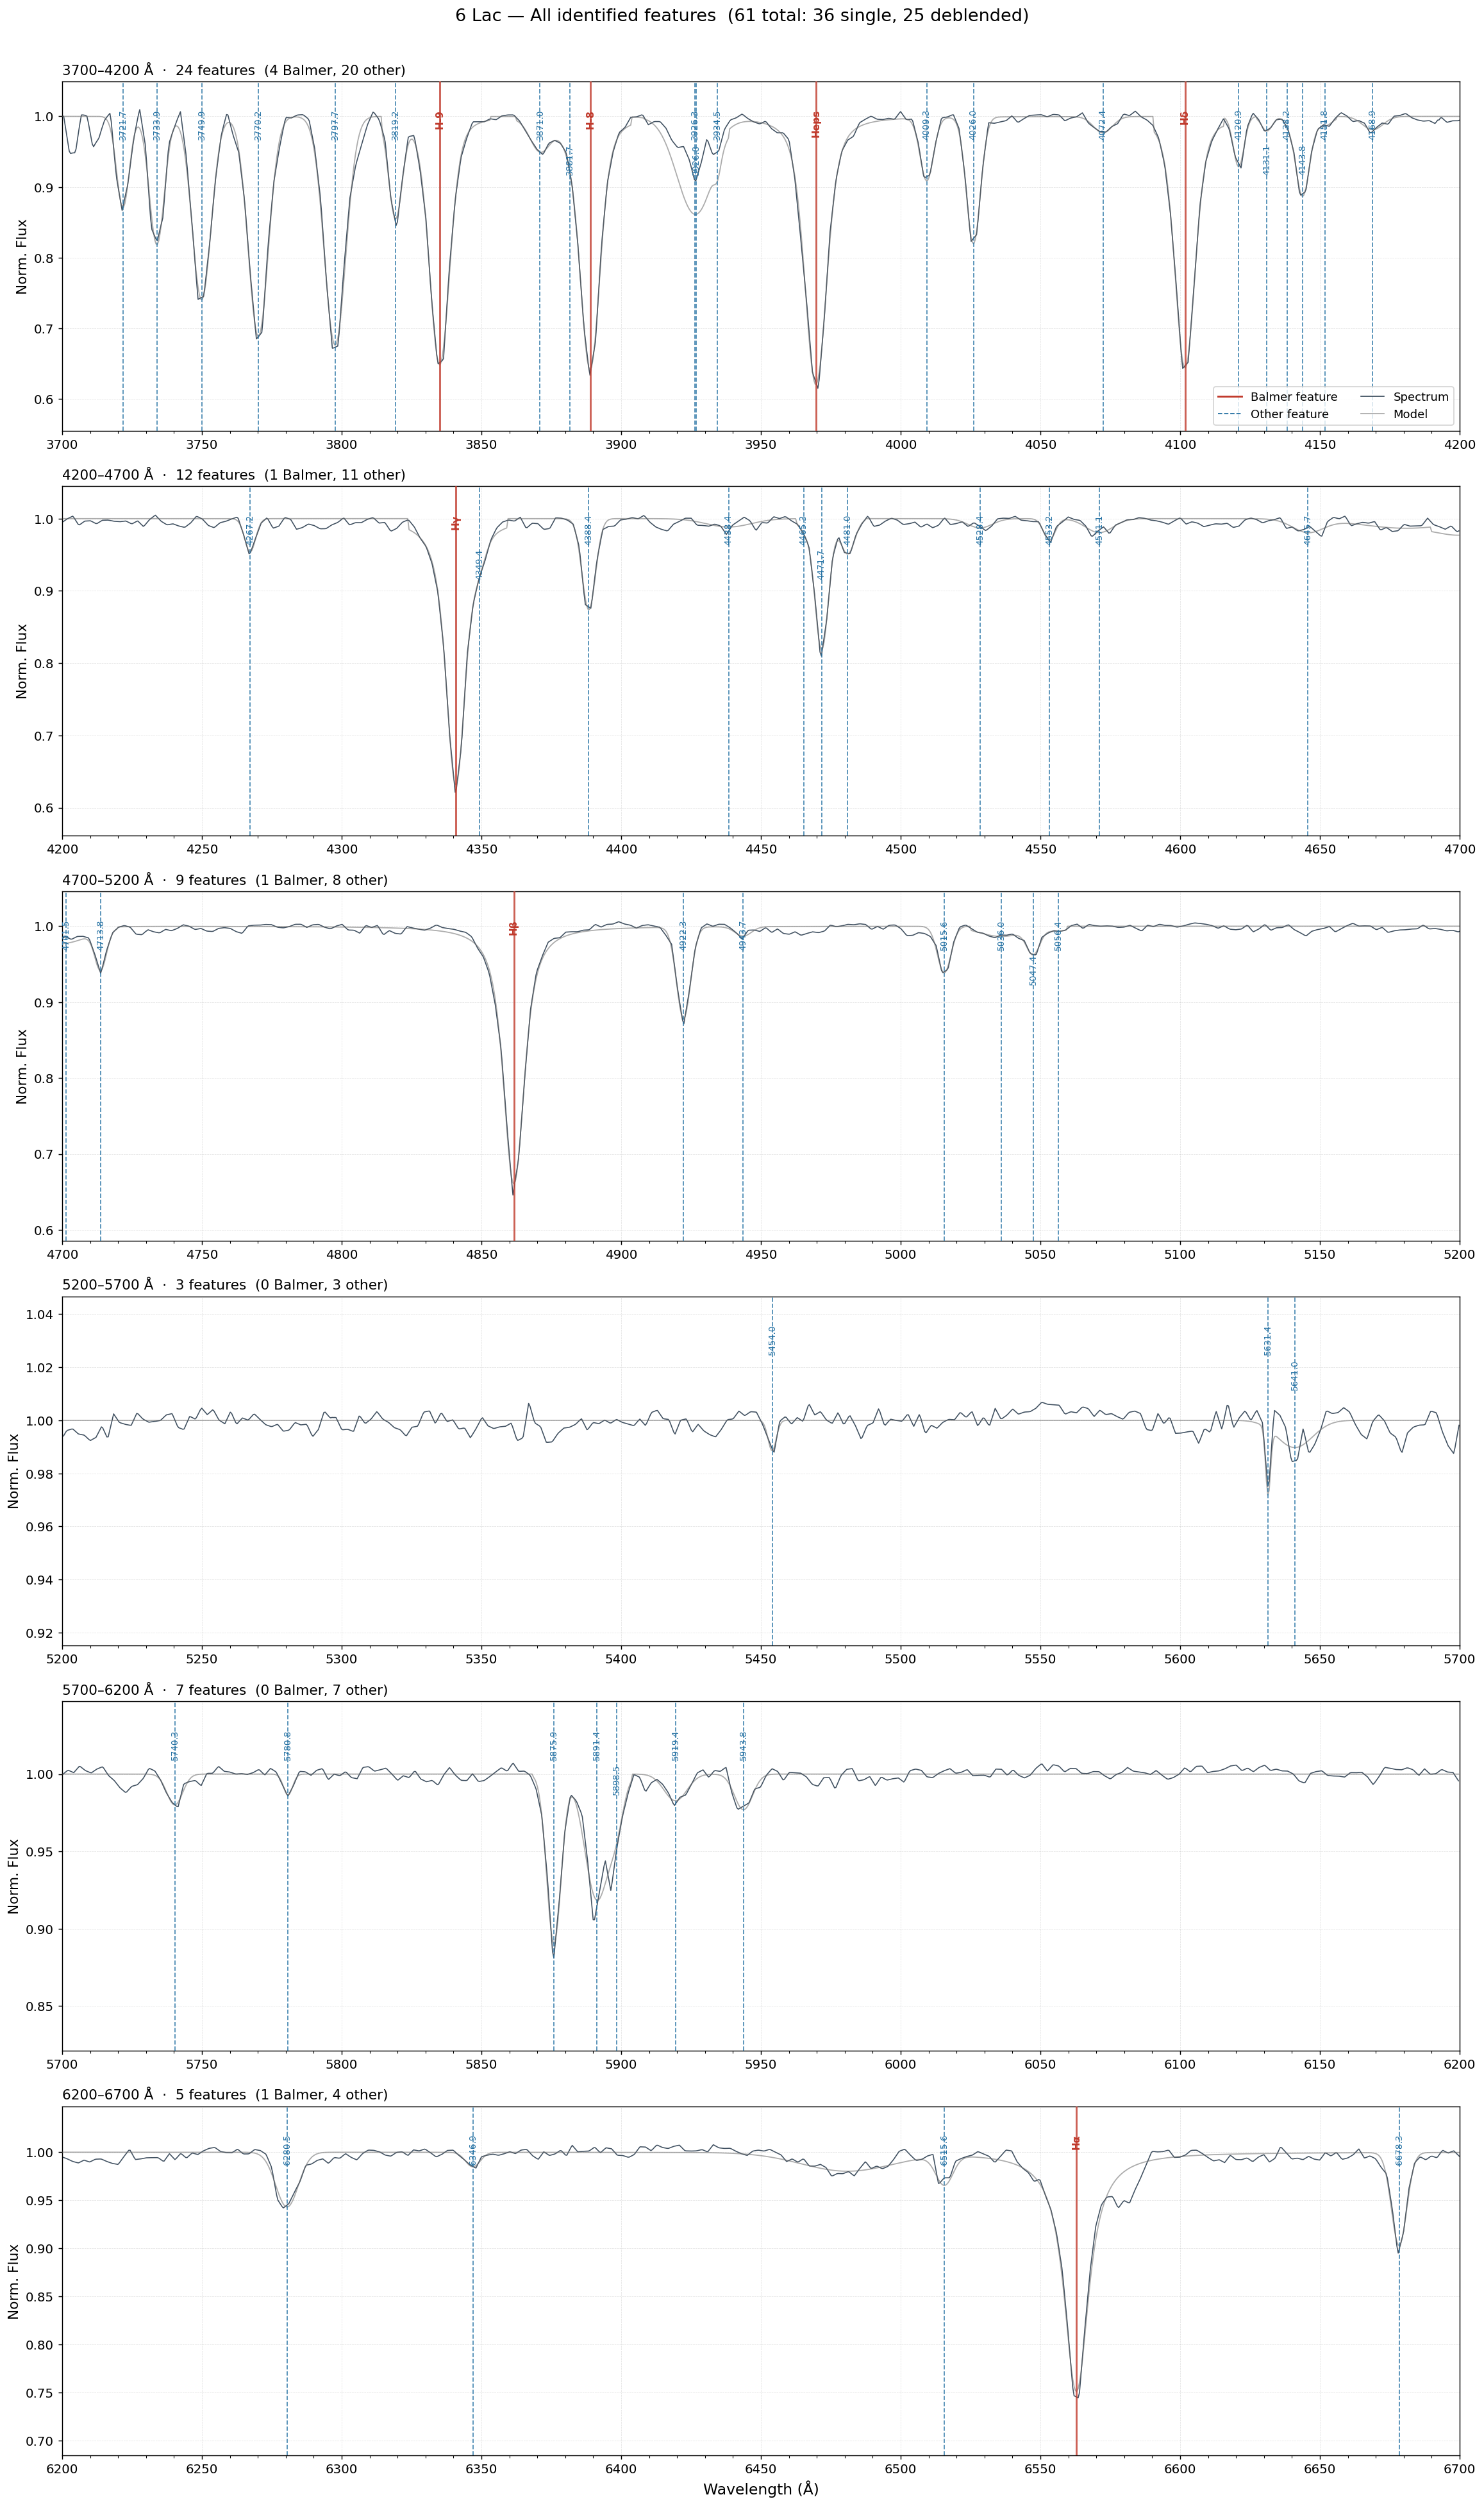


Features per panel:
  3700–4200 Å : 24
  4200–4700 Å : 12
  4700–5200 Å : 9
  5200–5700 Å : 3
  5700–6200 Å : 7
  6200–6700 Å : 5


In [18]:
# ── Build composite model spectrum for overlay ─────────────────────────────────
model_spectrum = np.zeros_like(flux)

for pk, (tag, name) in zip(peaks, classifications):
    if pk in deblended_pks:
        continue
    r = fit_by_pk.get(pk)
    if not r:
        continue
    if r['profile'] == 'Voigt':
        amp, cen, sg, sl = r['popt']
        y = voigt_norm(wavelength, amp, cen, sg, sl)
    elif r['profile'] == 'Composite':
        y = composite_balmer(wavelength, *r['popt'])
    else:
        amp, cen, sg = r['popt']
        y = gaussian(wavelength, amp, cen, sg)
    model_spectrum += y

for (il, ir), res in blend_results.items():
    if not res['success']:
        continue
    x_reg = res['x_reg']
    m_reg = (wavelength >= x_reg[0]) & (wavelength <= x_reg[-1])
    for comp in res['components']:
        if comp['profile'] == 'V':
            sl_val = comp['sl'] if comp['sl'] is not None else 0.
            y_c = voigt_norm(x_reg, comp['amp'], comp['cen'], comp['sg'], sl_val)
        else:
            y_c = gaussian(x_reg, comp['amp'], comp['cen'], comp['sg'])
        n_pts = m_reg.sum()
        model_spectrum[m_reg] += y_c[:n_pts]

if PLOT_FINAL_OVERVIEW:
    # ── Multi-panel overview plot ──────────────────────────────────────────────────
    panel_edges = np.arange(WL_MIN, WL_MAX + 1, PANEL_WIDTH_A)
    n_panels    = len(panel_edges) - 1
    fig, axes   = plt.subplots(n_panels, 1, figsize=(18, 5.0 * n_panels))
    if n_panels == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        lo, hi = panel_edges[i], panel_edges[i + 1]
        m_p = (wavelength >= lo) & (wavelength <= hi)

        ax.plot(wavelength[m_p], flux[m_p],
                color=C_SPEC, linewidth=0.9, alpha=0.9, zorder=2, label='Spectrum')
        ax.plot(wavelength[m_p], 1. - model_spectrum[m_p],
                color='dimgray', linewidth=1.0, alpha=0.55, zorder=3, label='Model')

        feats_in = [(f, f['wavelength_A'])
                    for f in features if lo <= f['wavelength_A'] <= hi]

        prev_wl = -9999; alt = False
        for f, wl_f in sorted(feats_in, key=lambda x: x[1]):
            colour = C_BALMER if f['tag'] == 'Balmer' else C_OTHER
            lw = 1.6 if f['tag'] == 'Balmer' else 1.0
            ls = '-'  if f['tag'] == 'Balmer' else '--'
            ax.axvline(wl_f, color=colour, linewidth=lw, linestyle=ls,
                       alpha=0.80, zorder=4)
            # stagger labels when features are close
            if wl_f - prev_wl < 12:
                alt = not alt
            else:
                alt = False
            y_frac = 0.92 - (0.10 if alt else 0.0)
            label  = f['balmer_name'] if f['balmer_name'] else f"{wl_f:.1f}"
            ax.text(wl_f, y_frac, label,
                    transform=ax.get_xaxis_transform(),
                    rotation=90,
                    fontsize=8.5 if f['tag'] == 'Balmer' else 7.5,
                    color=colour,
                    fontweight='bold' if f['tag'] == 'Balmer' else 'normal',
                    ha='center', va='top', zorder=5)
            prev_wl = wl_f

        ax.set_xlim(lo, hi)
        fl_sl = flux[m_p]
        ax.set_ylim(max(0., fl_sl.min() - 0.06),
                    min(fl_sl.max() + 0.04, 1.07))
        ax.set_ylabel('Norm. Flux', fontsize=12)
        n_b = sum(1 for f, _ in feats_in if f['tag'] == 'Balmer')
        n_o = sum(1 for f, _ in feats_in if f['tag'] != 'Balmer')
        ax.set_title(
            f"{lo}\u2013{hi} \u00c5  \u00b7  {len(feats_in)} features  "
            f"({n_b} Balmer, {n_o} other)",
            fontsize=12, loc='left')
        ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
        ax.xaxis.set_minor_locator(ticker.MultipleLocator(10))
        ax.tick_params(axis='both', labelsize=11)
        if i == n_panels - 1:
            ax.set_xlabel('Wavelength (\u00c5)', fontsize=13)

    axes[0].legend(handles=[
        Line2D([0],[0], color=C_BALMER, lw=1.6, ls='-',  label='Balmer feature'),
        Line2D([0],[0], color=C_OTHER,  lw=1.0, ls='--', label='Other feature'),
        Line2D([0],[0], color=C_SPEC,   lw=0.9,           label='Spectrum'),
        Line2D([0],[0], color='dimgray',lw=1.0, alpha=0.55, label='Model'),
    ], fontsize=10, loc='lower right', ncol=2)

    fig.suptitle(
        f'{OBJECT_NAME} — All identified features  '
        f'({len(features)} total: {n_single} single, {n_deblended} deblended)',
        fontsize=15, y=1.002)
    plt.tight_layout()
    plt.show()
    print(f'\nFeatures per panel:')
    for i in range(n_panels):
        lo2, hi2 = panel_edges[i], panel_edges[i+1]
        n = sum(1 for f in features if lo2 <= f['wavelength_A'] <= hi2)
        print(f'  {lo2}\u2013{hi2} \u00c5 : {n}')


### Spectral context

*The notes below describe the line forest typical of an early B-type star (the spectral class of the original ι Herculis dataset this notebook was developed against). If you are running this pipeline on a star of a different class, treat this section as a worked example rather than a universal reference — see the table further down for what to expect at other spectral types.*

For an early B star, at R = 850 the dominant features are:
- **Balmer series** (Hα, Hβ, Hγ, Hδ, Hε, …) — strong broad absorption  
- **He I** lines (4026, 4121, 4144, 4388, 4471, 4713, 4922, 5016, 5876, 6678 Å)  
- **Si II / Si III** lines in the 4552–4575, 5041, 6347/6371 Å regions  
- **Mg II** 4481 Å  
- **Ca II** H & K (3934, 3968 Å) — can have an interstellar/circumstellar component  
- **O II**, **N II** blends in the blue  
- **Na I D** doublet (5890/5896) — likely interstellar  

Most of these are blended at R ≈ 850, which is why this notebook uses **multi-component Voigt+Gaussian deblending**.

For other spectral classes, expect a different line forest:

| Class | Dominant features |
|-------|-------------------|
| O | Strong He II, weak Balmer, N III, C III |
| B (this example) | Strong Balmer, He I, Si II/III, Mg II |
| A | Very strong Balmer, weak metals, Ca II K |
| F | Balmer weakening, Fe I/II and Ca I forest emerging |

---

## Next steps (future cells)
1. **Line identification** — match all fitted centroids (single + deblended components) to a reference line list (NIST / Vienna Atomic Line Database).
2. **Summary table** — wavelength, equivalent width, depth, FWHM, identification for every detected feature.
